<a href="https://colab.research.google.com/github/Rogendo/MACHINE-LEARNING/blob/main/iTransformer_TimesNet_Focus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fusion-Trade Phase 1B — Self-Contained Multi-Model Benchmark

This notebook now includes a full Colab-ready pipeline:

1. Download Dukascopy historical market data.
2. Resample to 4H OHLCV.
3. Build baseline, FFT, and FFT+causal-STFT feature sets.
4. Create direction and tradeable-movement targets.
5. Benchmark tree models and sequence models.

The goal is to evaluate whether FFT/STFT representations improve predictive performance across multiple model families, not only XGBoost/LightGBM.

## 0. Colab setup and dependencies

This notebook is self-contained for Colab:

1. Install dependencies.
2. Download Dukascopy historical OHLC data.
3. Resample to 4H candles.
4. Build baseline / FFT / FFT+STFT datasets.
5. Benchmark XGBoost, LightGBM, Random Forest, MLP, LSTM, GRU, TCN, and a **real PatchTST classifier**.

No pre-uploaded CSV is required unless you choose to use your own data.


In [1]:
# Colab/Kaggle/local setup
# In Colab, run this cell. Locally, you can comment it out if packages are already installed.

!pip install -q numpy pandas scipy scikit-learn pyarrow xgboost lightgbm torch matplotlib dukascopy-python

## 1. Imports and configuration

In [2]:
import os, json, math, warnings, random
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import entropy as scipy_entropy
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception as e:
    HAS_XGB = False
    print('XGBoost unavailable:', e)

try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception as e:
    HAS_LGB = False
    print('LightGBM unavailable:', e)

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    HAS_TORCH = True
    DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
    torch.manual_seed(SEED)
    print('Torch device:', DEVICE)
except Exception as e:
    HAS_TORCH = False
    DEVICE = 'cpu'
    print('PyTorch unavailable:', e)

pd.set_option('display.max_columns', 120)

Torch device: cuda


## 2. Data source: download Dukascopy data inside the notebook

For experimentation in Colab, we should not rely on a manually uploaded CSV.

This section downloads Dukascopy data directly, converts it into the standard Fusion-Trade format:

```text
timestamp | open | high | low | close | volume
```

Then it resamples the data to the timeframe we want, for example **4H**.

### Why Dukascopy?

Dukascopy gives much deeper Forex/metal history than Yahoo Finance intraday data. We can download 1-minute data and resample it ourselves to 1H, 4H, daily, etc.

In [3]:
# ============================================================
# Dukascopy downloader + resampler
# ============================================================

from datetime import datetime
import os
import pandas as pd

# -----------------------------
# User configuration
# -----------------------------
USE_DUKASCOPY = False       # True = download data in notebook. False = use CSV_PATH below.
USE_SYNTHETIC = True      # True = use synthetic data instead of real data.

# Instrument options usually include: "XAUUSD", "EURUSD", "GBPUSD", "USDJPY", etc.
# For metals, use XAUUSD. For forex, use EURUSD, GBPUSD, etc.
DUKA_SYMBOL = "XAUUSD"

START_DATE = datetime(2003, 1, 1)
END_DATE   = datetime(2026, 6, 30)

# Dukascopy download granularity. For long ranges, 1H is much lighter.
# If you want maximum flexibility, use "1min" then resample, but it may take longer.
DUKA_INTERVAL = "1h"    # options depend on dukascopy-python: commonly "1min", "1h", "1d"
TARGET_TIMEFRAME = "4H"   # pandas resample rule: "1H", "4H", "1D", etc.

CSV_PATH = "real_data/XAUUSD_4H_dukascopy.csv"  # used if USE_DUKASCOPY=False
OUT_CSV_PATH = f"real_data/{DUKA_SYMBOL}_{TARGET_TIMEFRAME}_dukascopy.csv".replace("/", "_")


def make_synthetic(n: int = 3000, seed: int = 42) -> pd.DataFrame:
    """Fallback synthetic dataset with hidden weekly/monthly cycles."""
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    trend = 1900 + 0.05 * t
    weekly = 12 * np.sin(2*np.pi*t/7)
    monthly = 20 * np.sin(2*np.pi*t/30)
    vol_cycle = 1 + 0.5*np.abs(np.sin(2*np.pi*t/50))
    noise = rng.normal(0, 5*vol_cycle, n)
    close = np.maximum(trend + weekly + monthly + noise, 1)
    spread = rng.uniform(2, 8, n)
    high = close + spread * rng.uniform(0.4, 1.0, n)
    low = close - spread * rng.uniform(0.4, 1.0, n)
    open_ = close + rng.normal(0, 2, n)
    volume = rng.integers(1000, 50000, n).astype(float)
    dates = pd.date_range("2020-01-01", periods=n, freq="4H", tz="UTC")
    return pd.DataFrame({"timestamp": dates, "open": open_, "high": high, "low": low, "close": close, "volume": volume})


def _standardize_ohlcv_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Return timestamp/open/high/low/close/volume columns from common provider formats."""
    df = df.copy()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.reset_index() if df.index.name is not None or not isinstance(df.index, pd.RangeIndex) else df
    df.columns = [str(c).lower().replace(" ", "_") for c in df.columns]

    # Normalize timestamp column name
    for candidate in ["timestamp", "datetime", "date", "time", "index", "gmt_time"]:
        if candidate in df.columns:
            df = df.rename(columns={candidate: "timestamp"})
            break

    # Some Dukascopy outputs may use ask/bid variants; pick close/open/high/low if already present.
    required = ["timestamp", "open", "high", "low", "close"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required OHLC columns after standardization: {missing}. Available: {list(df.columns)}")

    if "volume" not in df.columns:
        # Dukascopy may sometimes return tick_volume or no volume depending on instrument/гранулярность.
        vol_candidates = [c for c in df.columns if "volume" in c]
        if vol_candidates:
            df = df.rename(columns={vol_candidates[0]: "volume"})
        else:
            df["volume"] = 0.0

    out = df[["timestamp", "open", "high", "low", "close", "volume"]].copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"], utc=True)
    for c in ["open", "high", "low", "close", "volume"]:
        out[c] = pd.to_numeric(out[c], errors="coerce")
    out = out.dropna().sort_values("timestamp").reset_index(drop=True)
    return out


def resample_ohlcv(df: pd.DataFrame, rule: str = "4H") -> pd.DataFrame:
    """Resample OHLCV to the requested timeframe."""
    df = _standardize_ohlcv_columns(df)
    out = (
        df.set_index("timestamp")
          .resample(rule)
          .agg({
              "open": "first",
              "high": "max",
              "low": "min",
              "close": "last",
              "volume": "sum",
          })
          .dropna()
          .reset_index()
    )
    return out


def download_dukascopy(symbol: str, start: datetime, end: datetime, interval: str = "1min") -> pd.DataFrame:
    """Download Dukascopy data using dukascopy-python, with a robust fallback for instrument names."""
    import dukascopy_python as dp

    # dukascopy-python can accept symbols in many builds, but some versions expose instrument constants.
    symbol_upper = symbol.upper().replace("/", "")

    # Try direct symbol first.
    try:
        df = dp.fetch(symbol_upper, interval=interval, start=start, end=end, offer_side='BID')
        return _standardize_ohlcv_columns(df)
    except Exception as e_direct:
        print(f"Direct symbol fetch failed for {symbol_upper}: {e_direct}")

    # Try common constants from dukascopy_python.instruments.
    try:
        import dukascopy_python.instruments as inst
        constant_names = [
            f"INSTRUMENT_FX_METALS_{symbol_upper[:3]}_{symbol_upper[3:]}",
            f"INSTRUMENT_FX_MAJORS_{symbol_upper[:3]}_{symbol_upper[3:]}",
            f"INSTRUMENT_FX_CROSSES_{symbol_upper[:3]}_{symbol_upper[3:]}",
        ]
        for name in constant_names:
            if hasattr(inst, name):
                instrument = getattr(inst, name)
                print(f"Using Dukascopy instrument constant: {name}")
                df = dp.fetch(instrument, interval=interval, start=start, end=end, offer_side='BID')
                return _standardize_ohlcv_columns(df)
    except Exception as e_const:
        print(f"Constant-based fetch also failed: {e_const}")

    raise RuntimeError(
        f"Could not download {symbol} from Dukascopy. Try a known symbol like XAUUSD, EURUSD, GBPUSD, or upload a CSV."
    )


# -----------------------------
# Build the raw dataframe
# -----------------------------
if USE_SYNTHETIC:
    df_raw = make_synthetic(n=3000)
    print("Using synthetic data")
elif USE_DUKASCOPY:
    print(f"Downloading Dukascopy {DUKA_SYMBOL} from {START_DATE.date()} to {END_DATE.date()} at {DUKA_INTERVAL}...")
    df_min = download_dukascopy(DUKA_SYMBOL, START_DATE, END_DATE, interval=DUKA_INTERVAL)
    print("Raw downloaded data:", df_min.shape)
    display(df_min.head())
    df_raw = resample_ohlcv(df_min, TARGET_TIMEFRAME)
    os.makedirs(os.path.dirname(OUT_CSV_PATH), exist_ok=True)
    df_raw.to_csv(OUT_CSV_PATH, index=False)
    print(f"Saved resampled data: {OUT_CSV_PATH} shape={df_raw.shape}")
else:
    print(f"Loading local CSV: {CSV_PATH}")
    df_raw = pd.read_csv(CSV_PATH)
    df_raw = _standardize_ohlcv_columns(df_raw)

print("Final OHLCV dataframe:")
display(df_raw.head())
print(df_raw.shape)


Using synthetic data
Final OHLCV dataframe:


,timestamp,open,high,low,close,volume
0,2020-01-01 00:00:00+00:00,1900.352765,1904.872356,1896.907525,1901.523585,39896.0
1,2020-01-01 04:00:00+00:00,1904.658137,1910.875404,1902.559973,1908.064430,40116.0
2,2020-01-01 08:00:00+00:00,1923.524783,1927.385479,1919.040775,1924.152698,3944.0
3,2020-01-01 12:00:00+00:00,1921.715282,1929.076622,1916.585964,1922.680746,16645.0
4,2020-01-01 16:00:00+00:00,1895.101099,1903.064678,1894.210059,1897.751320,47064.0


(3000, 6)


### Optional: download the resampled Dukascopy CSV from Colab

After the Dukascopy data is downloaded and resampled, this cell lets you download the generated CSV to your local machine for reuse.

In [4]:
# Optional Colab download of the generated CSV
try:
    from google.colab import files
    if os.path.exists(OUT_CSV_PATH):
        files.download(OUT_CSV_PATH)
except Exception as e:
    print("Not running in Colab, or download skipped:", e)


## 3. Feature engineering: baseline + FFT + causal STFT

This section keeps the Phase 1 fixes:

- FFT uses only historical candles.
- STFT is causal: row `t` only sees candles `<= t`.
- Phase is encoded as `sin`/`cos`, not raw radians.
- Datasets are aligned to the same valid rows.

In [5]:
# -----------------------------
# Baseline technical indicators
# -----------------------------

def add_baseline_features(df: pd.DataFrame, price_col: str = 'close') -> pd.DataFrame:
    df = df.copy()
    c = df[price_col]
    h = df['high']; l = df['low']; v = df['volume']
    df['log_return'] = np.log(c / c.shift(1))
    df['return_5'] = np.log(c / c.shift(5))
    df['range'] = h - l
    df['body'] = c - df['open']
    df['upper_wick'] = h - df[['open', price_col]].max(axis=1)
    df['lower_wick'] = df[['open', price_col]].min(axis=1) - l
    df['typical_price'] = (h + l + c) / 3
    for w in [10,20,50]:
        df[f'sma_{w}'] = c.rolling(w).mean()
        df[f'ema_{w}'] = c.ewm(span=w, adjust=False).mean()
    df['price_vs_sma20'] = c / (df['sma_20'] + 1e-9) - 1
    df['price_vs_ema20'] = c / (df['ema_20'] + 1e-9) - 1
    df['roc_5'] = c.pct_change(5)
    df['roc_20'] = c.pct_change(20)
    delta = c.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    df['rsi_14'] = 100 - (100 / (1 + gain/(loss + 1e-9)))
    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    df['macd'] = ema12 - ema26
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    df['macd_hist'] = df['macd'] - df['macd_signal']
    df['rolling_std_10'] = df['log_return'].rolling(10).std()
    df['rolling_std_20'] = df['log_return'].rolling(20).std()
    tr = pd.concat([(h-l), (h-c.shift(1)).abs(), (l-c.shift(1)).abs()], axis=1).max(axis=1)
    df['atr_14'] = tr.rolling(14).mean()
    bb_mid = c.rolling(20).mean()
    bb_std = c.rolling(20).std()
    df['bb_upper'] = bb_mid + 2*bb_std
    df['bb_lower'] = bb_mid - 2*bb_std
    df['bb_width'] = (df['bb_upper'] - df['bb_lower']) / (bb_mid + 1e-9)
    df['bb_pct'] = (c - df['bb_lower']) / (df['bb_upper'] - df['bb_lower'] + 1e-9)
    df['volume_ma20'] = v.rolling(20).mean()
    df['volume_ratio'] = v / (df['volume_ma20'] + 1e-9)
    ts = pd.to_datetime(df['timestamp'], utc=True)
    df['hour'] = ts.dt.hour
    df['day_of_week'] = ts.dt.dayofweek
    df['month'] = ts.dt.month
    df['is_london'] = ((df['hour'] >= 7) & (df['hour'] < 16)).astype(int)
    df['is_newyork'] = ((df['hour'] >= 13) & (df['hour'] < 22)).astype(int)
    df['is_overlap'] = ((df['hour'] >= 13) & (df['hour'] < 16)).astype(int)
    return df

# -----------------------------
# FFT / STFT helpers
# -----------------------------

def _log_returns(prices: np.ndarray) -> np.ndarray:
    r = np.zeros_like(prices, dtype=float)
    r[1:] = np.log(prices[1:] / prices[:-1])
    return r


def _hanning_fft(signal: np.ndarray):
    n = len(signal)
    w = signal * np.hanning(n)
    vals = np.fft.rfft(w)
    freqs = np.fft.rfftfreq(n)
    amps = np.abs(vals)
    phases = np.angle(vals)
    return amps, phases, freqs


def _add_sincos(features: dict, prefix: str, phase: float):
    features[f'sin_{prefix}'] = float(np.sin(phase))
    features[f'cos_{prefix}'] = float(np.cos(phase))


def compute_fft_row(window_prices: np.ndarray, n_components: int = 5) -> dict:
    signal = _log_returns(window_prices)
    amps, phases, freqs = _hanning_fft(signal)
    amps_nd, phases_nd, freqs_nd = amps[1:], phases[1:], freqs[1:]
    top_idx = np.argsort(amps_nd)[::-1][:n_components]
    top_amps, top_freqs, top_phases = amps_nd[top_idx], freqs_nd[top_idx], phases_nd[top_idx]
    features = {}
    for i in range(n_components):
        a = float(top_amps[i]) if i < len(top_amps) else 0.0
        f = float(top_freqs[i]) if i < len(top_freqs) else 0.0
        p = float(top_phases[i]) if i < len(top_phases) else 0.0
        features[f'fft_amp_{i+1}'] = a
        features[f'fft_freq_{i+1}'] = f
        _add_sincos(features, f'fft_phase_{i+1}', p)
    dom_freq = top_freqs[0] if len(top_freqs) and top_freqs[0] > 0 else 1e-6
    features['fft_dominant_period'] = float(1.0 / dom_freq)
    total_energy = float(np.sum(amps_nd**2)) + 1e-9
    band = max(len(amps_nd)//3, 1)
    features['fft_spectral_energy'] = total_energy
    features['fft_low_freq_energy'] = float(np.sum(amps_nd[:band]**2)) / total_energy
    features['fft_mid_freq_energy'] = float(np.sum(amps_nd[band:2*band]**2)) / total_energy
    features['fft_high_freq_energy'] = float(np.sum(amps_nd[2*band:]**2)) / total_energy
    norm = amps_nd / (amps_nd.sum() + 1e-9)
    features['fft_spectral_entropy'] = float(scipy_entropy(norm + 1e-12))
    features['fft_cycle_strength'] = float(top_amps[0]**2) / total_energy if len(top_amps) else 0.0
    dom_phase = float(top_phases[0]) if len(top_phases) else 0.0
    _add_sincos(features, 'fft_dominant_phase', dom_phase)
    return features


def compute_causal_stft_row(window_prices: np.ndarray, nperseg: int = 32) -> dict:
    seg = window_prices[-nperseg:] if len(window_prices) >= nperseg else window_prices
    signal = _log_returns(seg)
    amps, phases, freqs = _hanning_fft(signal)
    amps_nd, phases_nd, freqs_nd = amps[1:], phases[1:], freqs[1:]
    total = float(amps_nd.sum()) + 1e-9
    band = max(len(amps_nd)//3, 1)
    dom_idx = int(np.argmax(amps_nd)) if len(amps_nd) else 0
    dom_freq = float(freqs_nd[dom_idx]) if len(freqs_nd) else 0.0
    dom_phase = float(phases_nd[dom_idx]) if len(phases_nd) else 0.0
    features = {
        'stft_dom_freq': dom_freq,
        'stft_dom_period': float(1.0/dom_freq) if dom_freq > 0 else 0.0,
        'stft_low_energy': float(amps_nd[:band].sum()) / total,
        'stft_mid_energy': float(amps_nd[band:2*band].sum()) / total,
        'stft_high_energy': float(amps_nd[2*band:].sum()) / total,
        'stft_centroid': float(np.sum(freqs_nd * amps_nd)) / total,
        'stft_entropy': float(scipy_entropy(amps_nd/total + 1e-12)),
    }
    _add_sincos(features, 'stft_dom_phase', dom_phase)
    return features


def add_signal_features(df: pd.DataFrame, price_col='close', fft_window=64, fft_components=5, stft_nperseg=32):
    df = df.copy()
    prices = df[price_col].values
    fft_rows, stft_rows = [], []
    for i in range(len(prices)):
        if i < fft_window - 1:
            fft_rows.append({}); stft_rows.append({})
            continue
        start = i - fft_window + 1
        win = prices[start:i+1]
        fft_rows.append(compute_fft_row(win, fft_components))
        stft_rows.append(compute_causal_stft_row(win, stft_nperseg))
    # causal spectral flux from previous row only
    for i in range(len(stft_rows)):
        if not stft_rows[i]:
            continue
        if i == 0 or not stft_rows[i-1]:
            stft_rows[i]['stft_spectral_flux'] = 0.0
        else:
            keys = ['stft_low_energy','stft_mid_energy','stft_high_energy']
            stft_rows[i]['stft_spectral_flux'] = float(np.sqrt(sum((stft_rows[i].get(k,0)-stft_rows[i-1].get(k,0))**2 for k in keys)))
    return pd.concat([df, pd.DataFrame(fft_rows), pd.DataFrame(stft_rows)], axis=1)

## 4. Targets

We keep the old targets for comparability, but add the new **tradeable movement target**.

### Trade target

Let:

```text
future_return_5 = log(close[t+5] / close[t])
atr_return = ATR_14[t] / close[t]
threshold = 0.5 * atr_return
```

Then:

```text
BUY      = +1 if future_return_5 > threshold
SELL     = -1 if future_return_5 < -threshold
NO_TRADE =  0 otherwise
```

For model training we encode:

```text
SELL=0, NO_TRADE=1, BUY=2
```

In [6]:
def add_targets(df: pd.DataFrame, price_col='close', horizon=5, atr_mult=0.5) -> pd.DataFrame:
    df = df.copy()
    c = df[price_col]
    fwd1 = np.log(c.shift(-1) / c)
    fwd5 = np.log(c.shift(-horizon) / c)
    df['target_return_1'] = fwd1
    df['target_direction_1'] = (fwd1 > 0).astype(int)
    df['target_return_5'] = fwd5
    df['target_direction_5'] = (fwd5 > 0).astype(int)
    # realized volatility over next horizon
    log_ret = np.log(c / c.shift(1))
    rv = pd.Series(index=df.index, dtype=float)
    for i in range(len(df) - horizon):
        rv.iloc[i] = log_ret.iloc[i+1:i+horizon+1].std()
    df['target_volatility_5'] = rv
    # tradeable movement target
    atr_return = df['atr_14'] / (c + 1e-9)
    threshold = atr_mult * atr_return
    trade = np.ones(len(df), dtype=float)  # 1 = NO_TRADE
    trade[fwd5 > threshold] = 2            # BUY
    trade[fwd5 < -threshold] = 0           # SELL
    trade[pd.isna(fwd5) | pd.isna(threshold)] = np.nan
    df['target_trade_signal_5'] = trade
    return df

TARGET_COLS = ['target_return_1','target_direction_1','target_return_5','target_direction_5','target_volatility_5','target_trade_signal_5']

## 5. Build aligned datasets

This creates the three ablation datasets:

- `baseline`
- `fft`
- `fft_stft`

In [7]:
def build_aligned_datasets(source_df: pd.DataFrame, fft_window=64, stft_nperseg=32, horizon=5, atr_mult=0.5):
    df = add_baseline_features(source_df)
    df = add_targets(df, horizon=horizon, atr_mult=atr_mult)
    df = add_signal_features(df, fft_window=fft_window, stft_nperseg=stft_nperseg)

    fft_cols = [c for c in df.columns if c.startswith('fft_') or c.startswith('sin_fft_') or c.startswith('cos_fft_')]
    stft_cols = [c for c in df.columns if c.startswith('stft_') or c.startswith('sin_stft_') or c.startswith('cos_stft_')]
    signal_cols = set(fft_cols + stft_cols)
    meta_cols = ['timestamp']
    baseline_cols = [c for c in df.columns if c not in set(TARGET_COLS) | set(meta_cols) | signal_cols]

    # valid rows: all signal cols, all targets, no NaN baseline cols
    all_needed = baseline_cols + fft_cols + stft_cols + TARGET_COLS
    valid_mask = df[all_needed].notna().all(axis=1)
    dfv = df.loc[valid_mask].reset_index(drop=True)

    print('Valid aligned rows:', len(dfv), 'from source rows:', len(source_df))
    print('Baseline features:', len(baseline_cols), 'FFT:', len(fft_cols), 'STFT:', len(stft_cols))
    datasets = {
        'baseline': dfv[meta_cols + baseline_cols + TARGET_COLS].copy(),
        'fft': dfv[meta_cols + baseline_cols + fft_cols + TARGET_COLS].copy(),
        'fft_stft': dfv[meta_cols + baseline_cols + fft_cols + stft_cols + TARGET_COLS].copy(),
    }
    for k,v in datasets.items():
        print(k, v.shape)
    return datasets, {'baseline_cols': baseline_cols, 'fft_cols': fft_cols, 'stft_cols': stft_cols}

datasets, colgroups = build_aligned_datasets(df_raw, fft_window=64, stft_nperseg=32, horizon=5, atr_mult=0.5)

display(datasets['fft_stft'].head())
print('Trade target distribution:')
print(datasets['fft_stft']['target_trade_signal_5'].value_counts(normalize=True).sort_index())

Valid aligned rows: 2932 from source rows: 3000
Baseline features: 41 FFT: 29 STFT: 10
baseline (2932, 48)
fft (2932, 77)
fft_stft (2932, 87)


,timestamp,open,high,low,close,volume,log_return,return_5,range,body,upper_wick,lower_wick,typical_price,sma_10,ema_10,sma_20,ema_20,sma_50,ema_50,price_vs_sma20,price_vs_ema20,roc_5,roc_20,rsi_14,macd,macd_signal,macd_hist,rolling_std_10,rolling_std_20,atr_14,bb_upper,bb_lower,bb_width,bb_pct,volume_ma20,volume_ratio,hour,day_of_week,month,is_london,is_newyork,is_overlap,fft_amp_1,fft_freq_1,sin_fft_phase_1,cos_fft_phase_1,fft_amp_2,fft_freq_2,sin_fft_phase_2,cos_fft_phase_2,fft_amp_3,fft_freq_3,sin_fft_phase_3,cos_fft_phase_3,fft_amp_4,fft_freq_4,sin_fft_phase_4,cos_fft_phase_4,fft_amp_5,fft_freq_5,sin_fft_phase_5,cos_fft_phase_5,fft_dominant_period,fft_spectral_energy,fft_low_freq_energy,fft_mid_freq_energy,fft_high_freq_energy,fft_spectral_entropy,fft_cycle_strength,sin_fft_dominant_phase,cos_fft_dominant_phase,stft_dom_freq,stft_dom_period,stft_low_energy,stft_mid_energy,stft_high_energy,stft_centroid,stft_entropy,sin_stft_dom_phase,cos_stft_dom_phase,stft_spectral_flux,target_return_1,target_direction_1,target_return_5,target_direction_5,target_volatility_5,target_trade_signal_5
0,2020-01-11 12:00:00+00:00,1919.766733,1923.080691,1916.669998,1919.299481,2930.0,0.008491,0.009944,6.410693,-0.467253,3.313957,2.629483,1919.683390,1894.999673,1899.518678,1894.144483,1898.064766,1899.062226,1899.864134,0.013280,0.011188,0.009994,-0.001028,59.632606,0.312644,-2.611909,2.924553,0.007817,0.006681,14.925703,1923.966090,1864.322876,0.031488,0.921758,23461.70,0.124884,12,5,1,1,0,0,0.083218,0.140625,0.107106,0.994248,0.056555,0.15625,-0.273547,-0.961859,0.036706,0.125,-0.073157,-0.997320,0.036556,0.484375,0.823463,-0.567370,0.034172,0.03125,0.301766,0.953382,7.111111,0.023423,0.568719,0.199401,0.231880,3.206927,0.295656,0.107106,0.994248,0.15625,6.4,0.457191,0.209205,0.333604,0.242585,2.559342,0.991842,-0.127470,0.000000,0.006982,1,-0.000920,0,0.005768,1.0
1,2020-01-11 16:00:00+00:00,1931.375485,1936.346774,1927.381312,1932.747579,47838.0,0.006982,0.011300,8.965462,1.372094,3.599195,3.994173,1932.158555,1901.368294,1905.560296,1894.839837,1901.367891,1899.550301,1901.153681,0.020006,0.016504,0.011364,0.007248,60.926032,3.004204,-1.488686,4.492890,0.007651,0.006854,15.391091,1927.590716,1862.088959,0.034568,1.078729,24575.40,1.946581,16,5,1,0,1,0,0.083332,0.140625,0.845057,0.534676,0.055214,0.15625,-0.926995,-0.375074,0.036636,0.125,-0.815479,-0.578786,0.036011,0.484375,-0.867388,0.497633,0.034181,0.03125,0.492834,0.870123,7.111111,0.022963,0.573258,0.203439,0.223303,3.201401,0.302407,0.845057,0.534676,0.15625,6.4,0.452674,0.193024,0.354302,0.248315,2.570412,0.497353,-0.867548,0.026658,0.002777,1,-0.010895,0,0.004175,0.0
2,2020-01-11 20:00:00+00:00,1938.139774,1944.998447,1933.198806,1938.122674,41151.0,0.002777,0.027592,11.799640,-0.017100,6.858672,4.923868,1938.773309,1907.989130,1911.480729,1896.302401,1904.868346,1900.236906,1902.603445,0.022054,0.017458,0.027976,0.015324,61.566071,5.507523,-0.089444,5.596967,0.007628,0.006744,15.771862,1933.939679,1858.665123,0.039695,1.055570,26478.75,1.554114,20,5,1,0,1,0,0.083473,0.140625,0.944365,-0.328900,0.053773,0.15625,-0.867592,0.497277,0.036404,0.125,-0.965257,0.261301,0.035531,0.484375,0.905005,-0.425402,0.034212,0.03125,0.662102,0.749414,7.111111,0.022500,0.577630,0.206607,0.215763,3.194354,0.309677,0.944365,-0.328900,0.15625,6.4,0.446388,0.182334,0.371278,0.253540,2.584638,-0.396373,-0.918090,0.021023,-0.006796,0,-0.013273,0,0.003560,0.0
3,2020-01-12 00:00:00+00:00,1926.967249,1926.199226,1923.180715,1924.995270,35275.0,-0.006796,0.016754,3.018510,-1.971979,-0.768023,1.814555,1924.791737,1911.879605,1913.937918,1897.635073,1906.785196,1900.516435,1903.481556,0.014418,0.009550,0.016895,0.014040,63.701625,6.358849,1.200214,5.158635,0.008111,0.006812,15.286535,1937.403570,1857.866575,0.041914,0.843993,27923.60,1.263268,0,6,1,0,0,0,0.083664,0.140625,0.330129,-0.943936,0.052252,0.15625,-0.149889,0.988703,0.036001,0.125,-0.410267,0.911965,0.035120,0.484375,-0.936318,0.351153,0.034262,0.031

Trade target distribution:
target_trade_signal_5
0.0    0.377899
1.0    0.234652
2.0    0.387449
Name: proportion, dtype: float64


### Build the three aligned feature sets

This cell converts the downloaded/resampled OHLCV data into three comparable datasets:

- `baseline`: OHLCV + technical indicators
- `fft`: baseline + rolling FFT features
- `fft_stft`: baseline + rolling FFT + causal STFT features

The rows are aligned so all feature sets use the same timestamps.

In [8]:
# Feature/target configuration
FFT_WINDOW = 64
STFT_NPERSEG = 32
TARGET_HORIZON = 5
ATR_MULT = 0.5

# Build aligned datasets from the dataframe downloaded/resampled above.
datasets, colgroups = build_aligned_datasets(
    df_raw,
    fft_window=FFT_WINDOW,
    stft_nperseg=STFT_NPERSEG,
    horizon=TARGET_HORIZON,
    atr_mult=ATR_MULT,
)

for name, d in datasets.items():
    print(name, d.shape)
    display(d.head(2))

# Save the generated datasets for reuse.
os.makedirs('benchmark_data', exist_ok=True)
for name, d in datasets.items():
    out_path = f'benchmark_data/features_{name}.parquet'
    d.to_parquet(out_path, index=False)
    print('Saved:', out_path)

Valid aligned rows: 2932 from source rows: 3000
Baseline features: 41 FFT: 29 STFT: 10
baseline (2932, 48)
fft (2932, 77)
fft_stft (2932, 87)
baseline (2932, 48)


,timestamp,open,high,low,close,volume,log_return,return_5,range,body,upper_wick,lower_wick,typical_price,sma_10,ema_10,sma_20,ema_20,sma_50,ema_50,price_vs_sma20,price_vs_ema20,roc_5,roc_20,rsi_14,macd,macd_signal,macd_hist,rolling_std_10,rolling_std_20,atr_14,bb_upper,bb_lower,bb_width,bb_pct,volume_ma20,volume_ratio,hour,day_of_week,month,is_london,is_newyork,is_overlap,target_return_1,target_direction_1,target_return_5,target_direction_5,target_volatility_5,target_trade_signal_5
0,2020-01-11 12:00:00+00:00,1919.766733,1923.080691,1916.669998,1919.299481,2930.0,0.008491,0.009944,6.410693,-0.467253,3.313957,2.629483,1919.683390,1894.999673,1899.518678,1894.144483,1898.064766,1899.062226,1899.864134,0.013280,0.011188,0.009994,-0.001028,59.632606,0.312644,-2.611909,2.924553,0.007817,0.006681,14.925703,1923.966090,1864.322876,0.031488,0.921758,23461.7,0.124884,12,5,1,1,0,0,0.006982,1,-0.000920,0,0.005768,1.0
1,2020-01-11 16:00:00+00:00,1931.375485,1936.346774,1927.381312,1932.747579,47838.0,0.006982,0.011300,8.965462,1.372094,3.599195,3.994173,1932.158555,1901.368294,1905.560296,1894.839837,1901.367891,1899.550301,1901.153681,0.020006,0.016504,0.011364,0.007248,60.926032,3.004204,-1.488686,4.492890,0.007651,0.006854,15.391091,1927.590716,1862.088959,0.034568,1.078729,24575.4,1.946581,16,5,1,0,1,0,0.002777,1,-0.010895,0,0.004175,0.0


fft (2932, 77)


,timestamp,open,high,low,close,volume,log_return,return_5,range,body,upper_wick,lower_wick,typical_price,sma_10,ema_10,sma_20,ema_20,sma_50,ema_50,price_vs_sma20,price_vs_ema20,roc_5,roc_20,rsi_14,macd,macd_signal,macd_hist,rolling_std_10,rolling_std_20,atr_14,bb_upper,bb_lower,bb_width,bb_pct,volume_ma20,volume_ratio,hour,day_of_week,month,is_london,is_newyork,is_overlap,fft_amp_1,fft_freq_1,sin_fft_phase_1,cos_fft_phase_1,fft_amp_2,fft_freq_2,sin_fft_phase_2,cos_fft_phase_2,fft_amp_3,fft_freq_3,sin_fft_phase_3,cos_fft_phase_3,fft_amp_4,fft_freq_4,sin_fft_phase_4,cos_fft_phase_4,fft_amp_5,fft_freq_5,sin_fft_phase_5,cos_fft_phase_5,fft_dominant_period,fft_spectral_energy,fft_low_freq_energy,fft_mid_freq_energy,fft_high_freq_energy,fft_spectral_entropy,fft_cycle_strength,sin_fft_dominant_phase,cos_fft_dominant_phase,target_return_1,target_direction_1,target_return_5,target_direction_5,target_volatility_5,target_trade_signal_5
0,2020-01-11 12:00:00+00:00,1919.766733,1923.080691,1916.669998,1919.299481,2930.0,0.008491,0.009944,6.410693,-0.467253,3.313957,2.629483,1919.683390,1894.999673,1899.518678,1894.144483,1898.064766,1899.062226,1899.864134,0.013280,0.011188,0.009994,-0.001028,59.632606,0.312644,-2.611909,2.924553,0.007817,0.006681,14.925703,1923.966090,1864.322876,0.031488,0.921758,23461.7,0.124884,12,5,1,1,0,0,0.083218,0.140625,0.107106,0.994248,0.056555,0.15625,-0.273547,-0.961859,0.036706,0.125,-0.073157,-0.997320,0.036556,0.484375,0.823463,-0.567370,0.034172,0.03125,0.301766,0.953382,7.111111,0.023423,0.568719,0.199401,0.231880,3.206927,0.295656,0.107106,0.994248,0.006982,1,-0.000920,0,0.005768,1.0
1,2020-01-11 16:00:00+00:00,1931.375485,1936.346774,1927.381312,1932.747579,47838.0,0.006982,0.011300,8.965462,1.372094,3.599195,3.994173,1932.158555,1901.368294,1905.560296,1894.839837,1901.367891,1899.550301,1901.153681,0.020006,0.016504,0.011364,0.007248,60.926032,3.004204,-1.488686,4.492890,0.007651,0.006854,15.391091,1927.590716,1862.088959,0.034568,1.078729,24575.4,1.946581,16,5,1,0,1,0,0.083332,0.140625,0.845057,0.534676,0.055214,0.15625,-0.926995,-0.375074,0.036636,0.125,-0.815479,-0.578786,0.036011,0.484375,-0.867388,0.497633,0.034181,0.03125,0.492834,0.870123,7.111111,0.022963,0.573258,0.203439,0.223303,3.201401,0.302407,0.845057,0.534676,0.002777,1,-0.010895,0,0.004175,0.0


fft_stft (2932, 87)


,timestamp,open,high,low,close,volume,log_return,return_5,range,body,upper_wick,lower_wick,typical_price,sma_10,ema_10,sma_20,ema_20,sma_50,ema_50,price_vs_sma20,price_vs_ema20,roc_5,roc_20,rsi_14,macd,macd_signal,macd_hist,rolling_std_10,rolling_std_20,atr_14,bb_upper,bb_lower,bb_width,bb_pct,volume_ma20,volume_ratio,hour,day_of_week,month,is_london,is_newyork,is_overlap,fft_amp_1,fft_freq_1,sin_fft_phase_1,cos_fft_phase_1,fft_amp_2,fft_freq_2,sin_fft_phase_2,cos_fft_phase_2,fft_amp_3,fft_freq_3,sin_fft_phase_3,cos_fft_phase_3,fft_amp_4,fft_freq_4,sin_fft_phase_4,cos_fft_phase_4,fft_amp_5,fft_freq_5,sin_fft_phase_5,cos_fft_phase_5,fft_dominant_period,fft_spectral_energy,fft_low_freq_energy,fft_mid_freq_energy,fft_high_freq_energy,fft_spectral_entropy,fft_cycle_strength,sin_fft_dominant_phase,cos_fft_dominant_phase,stft_dom_freq,stft_dom_period,stft_low_energy,stft_mid_energy,stft_high_energy,stft_centroid,stft_entropy,sin_stft_dom_phase,cos_stft_dom_phase,stft_spectral_flux,target_return_1,target_direction_1,target_return_5,target_direction_5,target_volatility_5,target_trade_signal_5
0,2020-01-11 12:00:00+00:00,1919.766733,1923.080691,1916.669998,1919.299481,2930.0,0.008491,0.009944,6.410693,-0.467253,3.313957,2.629483,1919.683390,1894.999673,1899.518678,1894.144483,1898.064766,1899.062226,1899.864134,0.013280,0.011188,0.009994,-0.001028,59.632606,0.312644,-2.611909,2.924553,0.007817,0.006681,14.925703,1923.966090,1864.322876,0.031488,0.921758,23461.7,0.124884,12,5,1,1,0,0,0.083218,0.140625,0.107106,0.994248,0.056555,0.15625,-0.273547,-0.961859,0.036706,0.125,-0.073157,-0.997320,0.036556,0.484375,0.823463,-0.567370,0.034172,0.03125,0.301766,0.953382,7.111111,0.023423,0.568719,0.199401,0.231880,3.206927,0.295656,0.107106,0.994248,0.15625,6.4,0.457191,0.209205,0.333604,0.242585,2.559342,0.991842,-0.127470,0.000000,0.006982,1,-0.000920,0,0.005768,1.0
1,2020-01-11 16:00:00+00:00,1931.375485,1936.346774,1927.381312,1932.747579,47838.0,0.006982,0.011300,8.965462,1.372094,3.599195,3.994173,1932.158555,1901.368294,1905.560296,1894.839837,1901.367891,1899.550301,1901.153681,0.020006,0.016504,0.011364,0.007248,60.926032,3.004204,-1.488686,4.492890,0.007651,0.006854,15.391091,1927.590716,1862.088959,0.034568,1.078729,24575.4,1.946581,16,5,1,0,1,0,0.083332,0.140625,0.845057,0.534676,0.055214,0.15625,-0.926995,-0.375074,0.036636,0.125,-0.815479,-0.578786,0.036011,0.484375,-0.867388,0.497633,0.034181,0.03125,0.492834,0.870123,7.111111,0.022963,0.573258,0.203439,0.223303,3.201401,0.302407,0.845057,0.534676,0.15625,6.4,0.452674,0.193024,0.354302,0.248315,2.570412,0.497353,-0.867548,0.026658,0.002777,1,-0.010895,0,0.004175,0.0


Saved: benchmark_data/features_baseline.parquet
Saved: benchmark_data/features_fft.parquet
Saved: benchmark_data/features_fft_stft.parquet


## 6. Common utilities for model benchmarking

We evaluate using a strict walk-forward split.

For sequence models, each sample contains a lookback window:

```text
X[i] = previous 64 rows × features
Y[i] = target at current row
```

For tree models, each sample is one row.

In [9]:
def get_feature_cols(df: pd.DataFrame):
    return [c for c in df.columns if c not in TARGET_COLS + ['timestamp']]


def make_splits(n_samples: int, n_splits=5, gap=5):
    return list(TimeSeriesSplit(n_splits=n_splits, gap=gap).split(np.arange(n_samples)))


def summarize_clf(y_true, y_pred, labels=None):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
        'weighted_f1': float(f1_score(y_true, y_pred, average='weighted', zero_division=0)),
    }


def safe_display_results(results):
    df = pd.DataFrame(results)
    cols = ['feature_set','target','model','accuracy','macro_f1','weighted_f1','n_features','n_train_avg','n_test_avg']
    cols = [c for c in cols if c in df.columns]
    return df[cols].sort_values(['target','feature_set','accuracy'], ascending=[True, True, False]).reset_index(drop=True)

## 7. Tree model benchmark

This is the same family as before, but now it includes the **tradeable movement target**.

In [10]:
def eval_tree_models(datasets: Dict[str, pd.DataFrame], targets=('target_direction_5','target_trade_signal_5'), n_splits=5, gap=5):
    results = []
    for feat_set, df in datasets.items():
        feat_cols = get_feature_cols(df)
        X_all = df[feat_cols].values.astype(np.float32)
        for target in targets:
            y_all = df[target].values.astype(int)
            splits = make_splits(len(df), n_splits=n_splits, gap=gap)
            model_specs = []
            if HAS_XGB:
                # binary or multiclass
                num_classes = len(np.unique(y_all))
                if num_classes > 2:
                    model_specs.append(('xgboost', lambda: xgb.XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, objective='multi:softprob', num_class=num_classes, eval_metric='mlogloss', random_state=SEED, verbosity=0)))
                else:
                    model_specs.append(('xgboost', lambda: xgb.XGBClassifier(n_estimators=250, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric='logloss', random_state=SEED, verbosity=0)))
            if HAS_LGB:
                model_specs.append(('lightgbm', lambda: lgb.LGBMClassifier(n_estimators=250, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, random_state=SEED, verbose=-1)))
            model_specs.append(('random_forest', lambda: RandomForestClassifier(n_estimators=250, max_depth=8, min_samples_leaf=5, random_state=SEED, n_jobs=-1)))
            for model_name, factory in model_specs:
                fold_scores = []
                ntr, nte = [], []
                for tr, te in splits:
                    scaler = StandardScaler()
                    Xtr = scaler.fit_transform(X_all[tr]); Xte = scaler.transform(X_all[te])
                    ytr, yte = y_all[tr], y_all[te]
                    model = factory()
                    model.fit(Xtr, ytr)
                    pred = model.predict(Xte)
                    fold_scores.append(summarize_clf(yte, pred))
                    ntr.append(len(tr)); nte.append(len(te))
                out = {'feature_set': feat_set, 'target': target, 'model': model_name, 'n_features': len(feat_cols), 'n_train_avg': int(np.mean(ntr)), 'n_test_avg': int(np.mean(nte))}
                for metric in fold_scores[0]:
                    out[metric] = float(np.mean([s[metric] for s in fold_scores]))
                    out[metric+'_std'] = float(np.std([s[metric] for s in fold_scores]))
                print(f"{feat_set:9s} | {target:22s} | {model_name:13s} acc={out['accuracy']:.4f} macroF1={out['macro_f1']:.4f}")
                results.append(out)
    return pd.DataFrame(results)

tree_results = eval_tree_models(datasets, targets=('target_direction_5','target_trade_signal_5'), n_splits=5, gap=5)
display(safe_display_results(tree_results.to_dict('records')))

baseline  | target_direction_5     | xgboost       acc=0.8475 macroF1=0.8468
baseline  | target_direction_5     | lightgbm      acc=0.8406 macroF1=0.8397
baseline  | target_direction_5     | random_forest acc=0.7832 macroF1=0.7758
baseline  | target_trade_signal_5  | xgboost       acc=0.7131 macroF1=0.6467
baseline  | target_trade_signal_5  | lightgbm      acc=0.7102 macroF1=0.6459
baseline  | target_trade_signal_5  | random_forest acc=0.6500 macroF1=0.5413
fft       | target_direction_5     | xgboost       acc=0.8758 macroF1=0.8757
fft       | target_direction_5     | lightgbm      acc=0.8730 macroF1=0.8728
fft       | target_direction_5     | random_forest acc=0.8324 macroF1=0.8292
fft       | target_trade_signal_5  | xgboost       acc=0.7377 macroF1=0.6717
fft       | target_trade_signal_5  | lightgbm      acc=0.7320 macroF1=0.6668
fft       | target_trade_signal_5  | random_forest acc=0.6926 macroF1=0.5971
fft_stft  | target_direction_5     | xgboost       acc=0.8713 macroF1=0.8712

,feature_set,target,model,accuracy,macro_f1,weighted_f1,n_features,n_train_avg,n_test_avg
0,baseline,target_direction_5,xgboost,0.847541,0.846786,0.846802,41,1463,488
1,baseline,target_direction_5,lightgbm,0.840574,0.839742,0.839747,41,1463,488
2,baseline,target_direction_5,random_forest,0.783197,0.775757,0.775632,41,1463,488
3,fft,target_direction_5,xgboost,0.875820,0.875744,0.875770,70,1463,488
4,fft,target_direction_5,lightgbm,0.872951,0.872757,0.872821,70,1463,488
5,fft,target_direction_5,random_forest,0.832377,0.829192,0.829103,70,1463,488
6,fft_stft,target_direction_5,xgboost,0.871311,0.871211,0.871251,80,1463,488
7,fft_stft,target_direction_5,lightgbm,0.870902,0.870696,0.870744,80,1463,488
8,fft_stft,target_direction_5,random_forest,0.822951,0.818638,0.818461,80,1463,488
9,baseline,target_trade_signal_5,xgboost,0.713115,0.646677,0.689890,41,1463,488


## 8. Deep sequence model utilities

We now test whether sequence models can exploit the same features better than row-level tree models.

Models included:

- **MLP**: neural tabular baseline using the last row only
- **LSTM**: sequence memory model
- **GRU**: lighter recurrent model
- **TCN**: temporal convolutional network
- **Real PatchTST classifier**: channel-independent patching, shared patch embedding, Transformer encoder over patches, and classification head

Important: the sequence benchmark uses an **effective gap of `lookback + horizon_gap`** so train and test windows do not share overlapping input history near fold boundaries.


In [11]:
if HAS_TORCH:
    class SeqDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.tensor(X, dtype=torch.float32)
            self.y = torch.tensor(y, dtype=torch.long)
        def __len__(self): return len(self.y)
        def __getitem__(self, idx): return self.X[idx], self.y[idx]

    def make_sequence_arrays(df, feat_cols, target_col, lookback=64):
        """
        Build causal supervised sequences.

        For row i, the input contains rows [i-lookback+1, ..., i].
        The target is target_col at row i. The target_col itself must already
        have been shifted forward during target engineering.
        """
        Xraw = df[feat_cols].values.astype(np.float32)
        yraw = df[target_col].values.astype(int)
        Xseq, yseq, idxs = [], [], []
        for i in range(lookback-1, len(df)):
            Xseq.append(Xraw[i-lookback+1:i+1])
            yseq.append(yraw[i])
            idxs.append(i)
        return np.asarray(Xseq, dtype=np.float32), np.asarray(yseq, dtype=np.int64), np.asarray(idxs)

    def train_val_predict_torch(model, Xtr, ytr, Xte, yte, epochs=15, batch_size=128, lr=1e-3, patience=4, verbose=False):
        """Train a PyTorch classifier with time-ordered validation split."""
        n = len(Xtr)
        cut = max(int(n*0.85), 1)
        X_train, y_train = Xtr[:cut], ytr[:cut]
        X_val, y_val = Xtr[cut:], ytr[cut:]
        if len(X_val) < 20:
            X_train, y_train, X_val, y_val = Xtr, ytr, Xtr, ytr

        train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(SeqDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

        model = model.to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
        loss_fn = nn.CrossEntropyLoss()
        best_state, best_val = None, 1e9
        bad = 0

        for ep in range(epochs):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

            model.eval(); vloss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    vloss += loss_fn(model(xb), yb).item() * len(yb)
            vloss /= max(len(X_val), 1)

            if vloss < best_val:
                best_val = vloss
                best_state = {k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        test_loader = DataLoader(SeqDataset(Xte, yte), batch_size=batch_size, shuffle=False)
        preds=[]
        model.eval()
        with torch.no_grad():
            for xb, yb in test_loader:
                logits = model(xb.to(DEVICE))
                preds.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
        return np.array(preds)

    class MLPClassifierNN(nn.Module):
        def __init__(self, n_features, n_classes, hidden=128):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_features, hidden), nn.ReLU(), nn.Dropout(0.2),
                nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(0.1),
                nn.Linear(hidden//2, n_classes)
            )
        def forward(self, x):
            if x.ndim == 3:
                x = x[:, -1, :]
            return self.net(x)

    class LSTMClassifier(nn.Module):
        def __init__(self, n_features, n_classes, hidden=96, layers=1):
            super().__init__()
            self.lstm = nn.LSTM(n_features, hidden, num_layers=layers, batch_first=True, dropout=0 if layers==1 else 0.1)
            self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Dropout(0.2), nn.Linear(hidden, n_classes))
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.head(out[:, -1, :])

    class GRUClassifier(nn.Module):
        def __init__(self, n_features, n_classes, hidden=96, layers=1):
            super().__init__()
            self.gru = nn.GRU(n_features, hidden, num_layers=layers, batch_first=True, dropout=0 if layers==1 else 0.1)
            self.head = nn.Sequential(nn.LayerNorm(hidden), nn.Dropout(0.2), nn.Linear(hidden, n_classes))
        def forward(self, x):
            out, _ = self.gru(x)
            return self.head(out[:, -1, :])

    class Chomp1d(nn.Module):
        def __init__(self, chomp_size):
            super().__init__(); self.chomp_size = chomp_size
        def forward(self, x):
            return x[:, :, :-self.chomp_size] if self.chomp_size > 0 else x

    class TCNBlock(nn.Module):
        def __init__(self, in_ch, out_ch, kernel=3, dilation=1):
            super().__init__()
            pad = (kernel-1)*dilation
            self.conv = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation), Chomp1d(pad), nn.ReLU(), nn.Dropout(0.15),
                nn.Conv1d(out_ch, out_ch, kernel, padding=pad, dilation=dilation), Chomp1d(pad), nn.ReLU(), nn.Dropout(0.15),
            )
            self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        def forward(self, x):
            return self.conv(x) + self.down(x)

    class TCNClassifier(nn.Module):
        def __init__(self, n_features, n_classes, hidden=64):
            super().__init__()
            self.net = nn.Sequential(
                TCNBlock(n_features, hidden, dilation=1),
                TCNBlock(hidden, hidden, dilation=2),
                TCNBlock(hidden, hidden, dilation=4),
            )
            self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(), nn.LayerNorm(hidden), nn.Linear(hidden, n_classes))
        def forward(self, x):
            x = x.transpose(1,2)
            z = self.net(x)
            return self.head(z)

    class RevIN(nn.Module):
        """
        Reversible instance normalization, commonly used with PatchTST-style models.
        Here we only use normalization for classification; denormalization is unnecessary.
        """
        def __init__(self, n_features, eps=1e-5, affine=True):
            super().__init__()
            self.eps = eps
            self.affine = affine
            if affine:
                self.weight = nn.Parameter(torch.ones(1, 1, n_features))
                self.bias = nn.Parameter(torch.zeros(1, 1, n_features))
        def forward(self, x):
            # x: [B, T, C]
            mean = x.mean(dim=1, keepdim=True)
            std = x.std(dim=1, keepdim=True).clamp_min(self.eps)
            x = (x - mean) / std
            if self.affine:
                x = x * self.weight + self.bias
            return x

    class PatchTSTClassifier(nn.Module):
        """
        Real PatchTST-style classifier.

        Key PatchTST ideas implemented:
        1. Channel independence: each feature/channel is patched separately.
        2. Shared patch embedding: the same Linear(patch_len -> d_model) is shared across channels.
        3. Transformer encoder operates over patch tokens for each channel.
        4. Classification head aggregates channel embeddings.

        Input:  x [B, T, C]
        Output: logits [B, n_classes]
        """
        def __init__(
            self,
            n_features,
            n_classes,
            lookback=64,
            patch_len=16,
            stride=8,
            d_model=64,
            nhead=4,
            layers=3,
            dropout=0.15,
            use_revin=True,
        ):
            super().__init__()
            assert lookback >= patch_len, "lookback must be >= patch_len"
            self.n_features = n_features
            self.lookback = lookback
            self.patch_len = patch_len
            self.stride = stride
            self.n_patches = 1 + (lookback - patch_len) // stride
            self.use_revin = use_revin
            self.revin = RevIN(n_features) if use_revin else nn.Identity()

            # Shared patch embedding across all channels.
            self.patch_embed = nn.Linear(patch_len, d_model)
            self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
            self.dropout = nn.Dropout(dropout)

            enc_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout,
                batch_first=True,
                activation='gelu',
                norm_first=True,
            )
            self.encoder = nn.TransformerEncoder(enc_layer, num_layers=layers)

            # Each channel becomes one representation after patch pooling.
            # Then all channel embeddings are flattened for classification.
            self.head = nn.Sequential(
                nn.LayerNorm(n_features * d_model),
                nn.Linear(n_features * d_model, 256),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(256, n_classes),
            )

            nn.init.trunc_normal_(self.pos_embed, std=0.02)

        def forward(self, x):
            # x: [B, T, C]
            B, T, C = x.shape
            x = self.revin(x)

            # Channel independent view: [B, C, T]
            x = x.transpose(1, 2)

            # Patches per channel: [B, C, N, P]
            patches = x.unfold(dimension=2, size=self.patch_len, step=self.stride)
            N = patches.size(2)

            # Shared projection: [B, C, N, D]
            z = self.patch_embed(patches)
            z = z + self.pos_embed[:, :N, :].unsqueeze(1)
            z = self.dropout(z)

            # Transformer over patches, separately per channel: [B*C, N, D]
            z = z.reshape(B * C, N, -1)
            z = self.encoder(z)

            # Pool patches within each channel: [B, C, D]
            z = z.mean(dim=1).reshape(B, C, -1)

            # Flatten channels: [B, C*D]
            z = z.reshape(B, -1)
            return self.head(z)


## 9. Run deep sequence benchmark

This section now uses a real PatchTST classifier rather than the previous placeholder Transformer.

PatchTST-specific details:

- Each feature/channel is patched independently.
- A shared patch embedding maps each patch into the Transformer dimension.
- The Transformer learns relationships across patches for each channel.
- Channel embeddings are pooled and sent to the classification head.
- The split uses a sequence embargo of `lookback + gap` to reduce overlap leakage.


In [12]:
def eval_deep_models(datasets: Dict[str, pd.DataFrame], targets=('target_direction_5','target_trade_signal_5'), lookback=64, n_splits=5, gap=5, epochs=12):
    if not HAS_TORCH:
        print('PyTorch unavailable; skipping deep benchmark.')
        return pd.DataFrame()
    results=[]
    for feat_set, df in datasets.items():
        feat_cols = get_feature_cols(df)
        for target in targets:
            Xseq, yseq, row_idxs = make_sequence_arrays(df, feat_cols, target, lookback=lookback)
            n_classes = len(np.unique(yseq))

            # Important leakage guard:
            # Since adjacent sequences share input history, use lookback + target gap as the embargo.
            effective_gap = max(gap, lookback + gap)
            splits = make_splits(len(yseq), n_splits=n_splits, gap=effective_gap)

            model_factories = {
                'mlp_last_row': lambda: MLPClassifierNN(len(feat_cols), n_classes),
                'lstm': lambda: LSTMClassifier(len(feat_cols), n_classes),
                'gru': lambda: GRUClassifier(len(feat_cols), n_classes),
                'tcn': lambda: TCNClassifier(len(feat_cols), n_classes),
                'patchtst': lambda: PatchTSTClassifier(
                    len(feat_cols), n_classes,
                    lookback=lookback,
                    patch_len=16,
                    stride=8,
                    d_model=64,
                    nhead=4,
                    layers=3,
                    dropout=0.15,
                    use_revin=True,
                ),
            }
            for model_name, factory in model_factories.items():
                fold_scores=[]; ntr=[]; nte=[]
                for tr, te in splits:
                    # Scale using training fold only, across all timesteps/features.
                    scaler = StandardScaler()
                    B,T,F = Xseq[tr].shape
                    Xtr = scaler.fit_transform(Xseq[tr].reshape(-1,F)).reshape(-1,T,F)
                    Xte = scaler.transform(Xseq[te].reshape(-1,F)).reshape(-1,T,F)
                    ytr, yte = yseq[tr], yseq[te]
                    model = factory()
                    pred = train_val_predict_torch(model, Xtr, ytr, Xte, yte, epochs=epochs, batch_size=128, lr=1e-3, patience=4)
                    fold_scores.append(summarize_clf(yte, pred))
                    ntr.append(len(tr)); nte.append(len(te))
                out = {
                    'feature_set': feat_set,
                    'target': target,
                    'model': model_name,
                    'n_features': len(feat_cols),
                    'lookback': lookback,
                    'sequence_gap': effective_gap,
                    'n_train_avg': int(np.mean(ntr)),
                    'n_test_avg': int(np.mean(nte)),
                }
                for metric in fold_scores[0]:
                    out[metric] = float(np.mean([s[metric] for s in fold_scores]))
                    out[metric+'_std'] = float(np.std([s[metric] for s in fold_scores]))
                print(f"{feat_set:9s} | {target:22s} | {model_name:12s} acc={out['accuracy']:.4f} macroF1={out['macro_f1']:.4f}")
                results.append(out)
    return pd.DataFrame(results)

# This can take several minutes depending on CPU/GPU.
deep_results = eval_deep_models(
    datasets,
    targets=('target_direction_5','target_trade_signal_5'),
    lookback=64,
    n_splits=5,
    gap=5,
    epochs=12,
)

display(safe_display_results(deep_results.to_dict('records')) if len(deep_results) else deep_results)


baseline  | target_direction_5     | mlp_last_row acc=0.7582 macroF1=0.7320
baseline  | target_direction_5     | lstm         acc=0.8377 macroF1=0.8353
baseline  | target_direction_5     | gru          acc=0.8598 macroF1=0.8586
baseline  | target_direction_5     | tcn          acc=0.6586 macroF1=0.6127
baseline  | target_direction_5     | patchtst     acc=0.7950 macroF1=0.7948
baseline  | target_trade_signal_5  | mlp_last_row acc=0.6046 macroF1=0.5322
baseline  | target_trade_signal_5  | lstm         acc=0.6682 macroF1=0.6159
baseline  | target_trade_signal_5  | gru          acc=0.6854 macroF1=0.6254
baseline  | target_trade_signal_5  | tcn          acc=0.4577 macroF1=0.3056
baseline  | target_trade_signal_5  | patchtst     acc=0.6657 macroF1=0.6054
fft       | target_direction_5     | mlp_last_row acc=0.7540 macroF1=0.7224
fft       | target_direction_5     | lstm         acc=0.8092 macroF1=0.8032
fft       | target_direction_5     | gru          acc=0.8192 macroF1=0.8151
fft       | 

,feature_set,target,model,accuracy,macro_f1,weighted_f1,n_features,n_train_avg,n_test_avg
0,baseline,target_direction_5,gru,0.859833,0.858600,0.858664,41,1366,478
1,baseline,target_direction_5,lstm,0.837657,0.835323,0.835264,41,1366,478
2,baseline,target_direction_5,patchtst,0.794979,0.794795,0.794784,41,1366,478
3,baseline,target_direction_5,mlp_last_row,0.758159,0.731955,0.732674,41,1366,478
4,baseline,target_direction_5,tcn,0.658577,0.612699,0.612575,41,1366,478
5,fft,target_direction_5,gru,0.819247,0.815072,0.815307,70,1366,478
6,fft,target_direction_5,lstm,0.809205,0.803186,0.803132,70,1366,478
7,fft,target_direction_5,patchtst,0.791632,0.790192,0.790430,70,1366,478
8,fft,target_direction_5,mlp_last_row,0.753975,0.722377,0.723018,70,1366,478
9,fft,target_direction_5,tcn,0.670711,0.645347,0.645685,70,1366,478


## 10. Combined benchmark table

This table answers the main question:

> Which model architecture extracts the most useful information from baseline, FFT, and FFT+STFT features?

In [13]:
all_results = pd.concat([tree_results, deep_results], ignore_index=True) if len(deep_results) else tree_results.copy()

# Save results
os.makedirs('benchmark_results', exist_ok=True)
all_results.to_csv('benchmark_results/model_benchmark_results.csv', index=False)
print('Saved benchmark_results/model_benchmark_results.csv')

display(safe_display_results(all_results.to_dict('records')))

# Pivot: accuracy by model and feature set for each target
for target in all_results['target'].unique():
    print('\nTarget:', target)
    piv = all_results[all_results['target']==target].pivot_table(index='model', columns='feature_set', values='accuracy')
    if {'baseline','fft','fft_stft'}.issubset(set(piv.columns)):
        piv['best'] = piv[['baseline','fft','fft_stft']].max(axis=1)
        piv['uplift_vs_baseline'] = piv['best'] - piv['baseline']
    display(piv.sort_values('best' if 'best' in piv.columns else piv.columns[0], ascending=False))

Saved benchmark_results/model_benchmark_results.csv


,feature_set,target,model,accuracy,macro_f1,weighted_f1,n_features,n_train_avg,n_test_avg
0,baseline,target_direction_5,gru,0.859833,0.858600,0.858664,41,1366,478
1,baseline,target_direction_5,xgboost,0.847541,0.846786,0.846802,41,1463,488
2,baseline,target_direction_5,lightgbm,0.840574,0.839742,0.839747,41,1463,488
3,baseline,target_direction_5,lstm,0.837657,0.835323,0.835264,41,1366,478
4,baseline,target_direction_5,patchtst,0.794979,0.794795,0.794784,41,1366,478
5,baseline,target_direction_5,random_forest,0.783197,0.775757,0.775632,41,1463,488
6,baseline,target_direction_5,mlp_last_row,0.758159,0.731955,0.732674,41,1366,478
7,baseline,target_direction_5,tcn,0.658577,0.612699,0.612575,41,1366,478
8,fft,target_direction_5,xgboost,0.875820,0.875744,0.875770,70,1463,488
9,fft,target_direction_5,lightgbm,0.872951,0.872757,0.872821,70,1463,488



Target: target_direction_5


feature_set,baseline,fft,fft_stft,best,uplift_vs_baseline
model,,,,,
xgboost,0.847541,0.875820,0.871311,0.875820,0.028279
lightgbm,0.840574,0.872951,0.870902,0.872951,0.032377
gru,0.859833,0.819247,0.814644,0.859833,0.000000
lstm,0.837657,0.809205,0.804184,0.837657,0.000000
random_forest,0.783197,0.832377,0.822951,0.832377,0.049180
patchtst,0.794979,0.791632,0.787448,0.794979,0.000000
mlp_last_row,0.758159,0.753975,0.746444,0.758159,0.000000
tcn,0.658577,0.670711,0.696234,0.696234,0.037657



Target: target_trade_signal_5


feature_set,baseline,fft,fft_stft,best,uplift_vs_baseline
model,,,,,
xgboost,0.713115,0.737705,0.744672,0.744672,0.031557
lightgbm,0.710246,0.731967,0.734426,0.734426,0.024180
random_forest,0.650000,0.692623,0.675820,0.692623,0.042623
gru,0.685356,0.675314,0.688285,0.688285,0.002929
patchtst,0.665690,0.661088,0.685774,0.685774,0.020084
lstm,0.668201,0.655649,0.651883,0.668201,0.000000
mlp_last_row,0.604603,0.615481,0.611715,0.615481,0.010879
tcn,0.457741,0.502510,0.494142,0.502510,0.044770


## 11. Visualize benchmark results

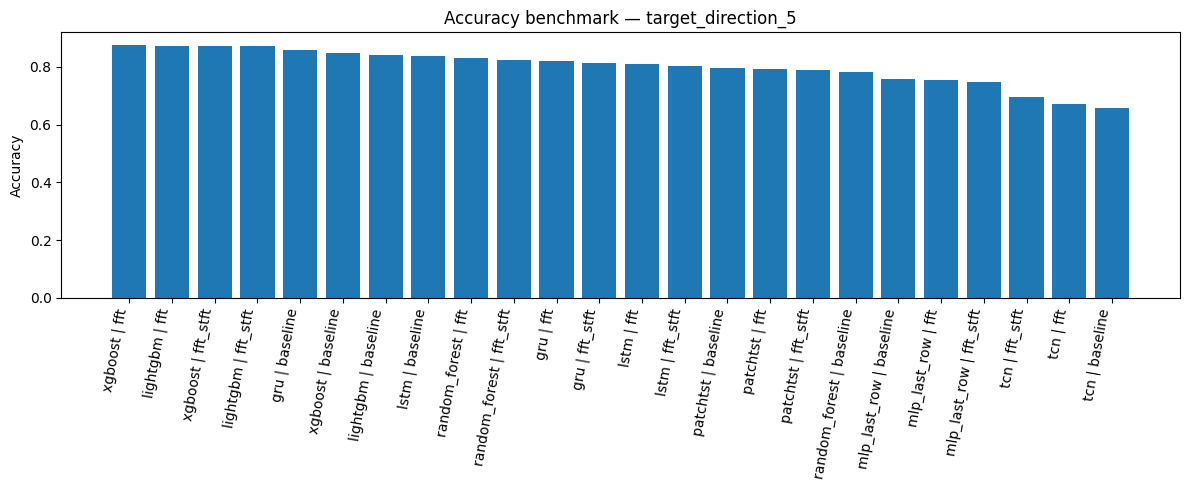

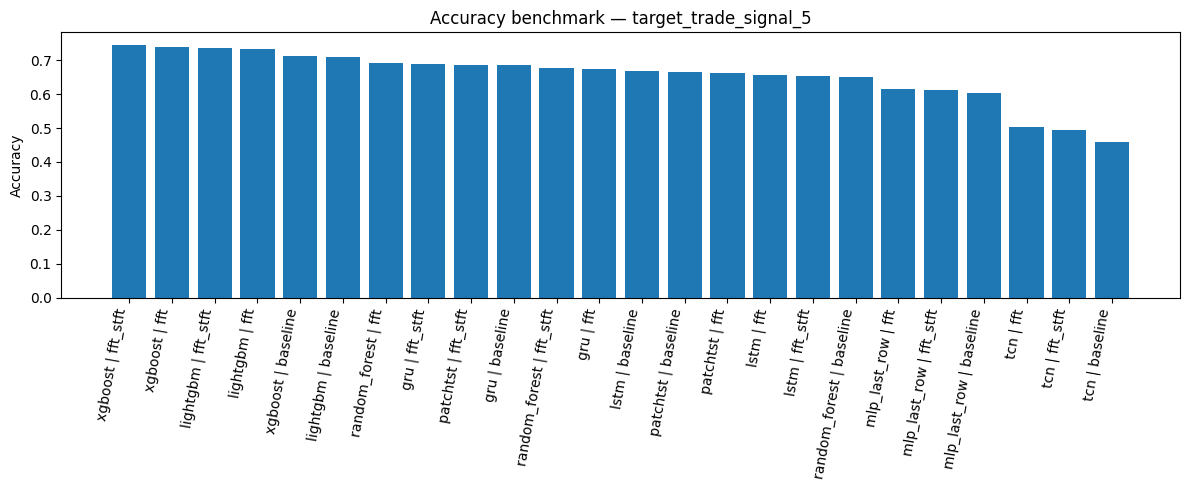

In [14]:
if len(all_results):
    for target in all_results['target'].unique():
        sub = all_results[all_results['target']==target].copy()
        plt.figure(figsize=(12,5))
        labels = sub['model'] + ' | ' + sub['feature_set']
        order = np.argsort(sub['accuracy'].values)[::-1]
        plt.bar(np.arange(len(sub)), sub['accuracy'].values[order])
        plt.xticks(np.arange(len(sub)), labels.values[order], rotation=80, ha='right')
        plt.title(f'Accuracy benchmark — {target}')
        plt.ylabel('Accuracy')
        plt.tight_layout()
        plt.show()

## 12. Interpretation guide

Use this logic:

### Case A — Deep sequence models beat tree models

Then the issue was probably architecture. FFT/STFT may need sequential learning.

### Case B — FFT/STFT improves trees and sequence models

Then frequency-domain features carry robust predictive information.

### Case C — FFT/STFT improves only tree models

Then FFT/STFT may be acting as handcrafted temporal memory. Sequence models may already learn similar temporal structure from the raw sequence.

### Case D — Real PatchTST improves strongly

Then patch-based temporal modeling is a promising path, and the previous placeholder result should be ignored.

### Case E — No architecture improves beyond baseline

Then the problem is likely target definition, missing external variables such as DXY/yields/news, or genuine market noise.


## 13. Bridge to Phase 2 — Market regime discovery

After this benchmark, Phase 2 should only begin once we know whether architecture was the bottleneck.

If FFT/STFT still mainly helps volatility/tradeable movement, Phase 2 becomes:

```text
FFT + STFT + indicators
↓
market regime discovery
↓
predict regime
↓
condition directional models on regime
```

PCA explained variance: [0.167 0.094 0.076 0.047 0.043 0.04  0.036 0.033] total= 0.536
Silhouette scores: [(3, np.float32(0.15758008)), (4, np.float32(0.15855375)), (5, np.float32(0.14745523)), (6, np.float32(0.13633637)), (7, np.float32(0.121904425)), (8, np.float32(0.12459173))]
Best k: 4


,count
discovered_regime,
0,711
1,511
2,637
3,1073


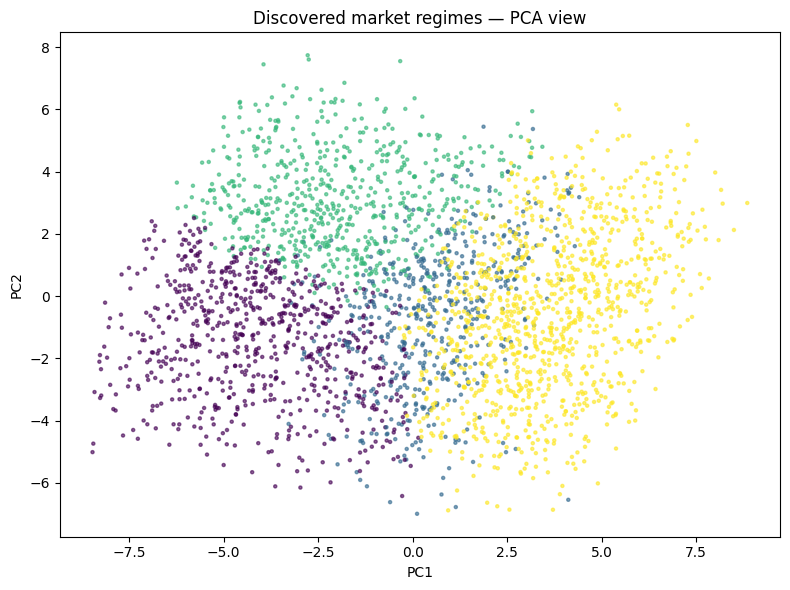

In [15]:
# Optional starter for Phase 2 regime discovery
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

regime_df = datasets['fft_stft'].copy()
feature_cols = get_feature_cols(regime_df)
X = regime_df[feature_cols].values.astype(np.float32)
X = StandardScaler().fit_transform(X)

pca = PCA(n_components=8, random_state=SEED)
Z = pca.fit_transform(X)
print('PCA explained variance:', pca.explained_variance_ratio_.round(3), 'total=', pca.explained_variance_ratio_.sum().round(3))

scores=[]
for k in range(3,9):
    km = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
    lab = km.fit_predict(Z)
    scores.append((k, silhouette_score(Z, lab)))
print('Silhouette scores:', scores)

best_k = max(scores, key=lambda x: x[1])[0]
km = KMeans(n_clusters=best_k, random_state=SEED, n_init='auto')
regime_df['discovered_regime'] = km.fit_predict(Z)
print('Best k:', best_k)
display(regime_df['discovered_regime'].value_counts().sort_index())

plt.figure(figsize=(8,6))
plt.scatter(Z[:,0], Z[:,1], c=regime_df['discovered_regime'], s=5, alpha=0.6)
plt.title('Discovered market regimes — PCA view')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout(); plt.show()


---

# Phase 1C — Audited Advanced Transformer Benchmark

This section upgrades the benchmark in four ways:

1. **Faithful PatchTST core**: channel independence, shared patch embedding, configurable `patch_len` / `stride`, learnable positional embedding over patches, and long contexts such as 256 and 512 candles.
2. **Long-context testing**: PatchTST is tested at longer lookbacks because the original PatchTST idea is especially useful when attention can see a longer history.
3. **Modern time-series Transformer baselines**: compact classifier adaptations of iTransformer, TimesNet, and FEDformer are added.
4. **Final leakage audit**: sequence splitting, scaling, and target alignment are checked again before results are trusted.

The implementation is **classifier-adapted** because our targets are `target_direction_5` and `target_trade_signal_5`, not future-value forecasting. The backbone ideas follow the papers:

- PatchTST: patching + channel independence + shared weights across channels. Source: https://arxiv.org/abs/2211.14730
- iTransformer: invert the usual Transformer dimensions so variables become tokens and each token embeds the full lookback. Source: https://arxiv.org/abs/2310.06625
- TimesNet: discover dominant periods and reshape 1D time series into 2D period tensors. Source: https://arxiv.org/abs/2210.02186
- FEDformer: use seasonal/trend decomposition and frequency-domain filtering. Source: https://proceedings.mlr.press/v162/zhou22g.html

Important naming: these are **classification adaptations** of the backbones, not drop-in official forecasting scripts.


In [16]:

# ============================================================
# Phase 1C — Evaluation audit utilities
# ============================================================

ADVANCED_TARGETS = ['target_direction_5', 'target_trade_signal_5']
DEFAULT_HORIZON = 5


def class_distribution_report(datasets, targets=ADVANCED_TARGETS):
    print('=== Class distribution by feature set and target ===')
    for fs, df in datasets.items():
        print(f'\n[{fs}] rows={len(df):,}')
        for target in targets:
            if target not in df.columns:
                print(f'  {target}: missing')
                continue
            counts = df[target].value_counts(dropna=False).sort_index()
            pct = (counts / len(df) * 100).round(2)
            print(f'  {target}:')
            for k in counts.index:
                print(f'    class {k}: {counts.loc[k]:>6}  ({pct.loc[k]:>5.2f}%)')


def audit_feature_safety(datasets):
    print('=== Feature safety audit ===')
    lengths = {k: len(v) for k, v in datasets.items()}
    print('Row counts:', lengths)
    assert len(set(lengths.values())) == 1, 'Dataset row counts differ. Ablation is not aligned.'
    for fs, df in datasets.items():
        feat_cols = get_feature_cols(df)
        bad = [c for c in feat_cols if c.startswith('target_') or c == 'timestamp']
        assert not bad, f'{fs}: target/meta columns leaked into features: {bad}'
        nan_count = df[feat_cols + [c for c in ADVANCED_TARGETS if c in df.columns]].isna().sum().sum()
        print(f'{fs:10s} features={len(feat_cols):3d}  NaNs in features/targets={nan_count}')
    print('✓ Feature sets are aligned and target columns are excluded from inputs.')


def make_sequence_arrays_with_index(df, feat_cols, target_col, lookback=256):
    """
    Create causal sequence samples.

    For sample ending at row i:
      input rows = [i-lookback+1, ..., i]
      target     = target_col[i]

    target_col must already be a forward-looking label created during target engineering.
    """
    valid = df[feat_cols + [target_col]].dropna().copy()
    Xraw = valid[feat_cols].values.astype(np.float32)
    yraw = valid[target_col].values.astype(int)
    # valid.index keeps original aligned row indices after dropna
    original_idx = valid.index.to_numpy()

    Xseq, yseq, end_idxs = [], [], []
    for j in range(lookback - 1, len(valid)):
        Xseq.append(Xraw[j - lookback + 1:j + 1])
        yseq.append(yraw[j])
        end_idxs.append(original_idx[j])
    return np.asarray(Xseq, dtype=np.float32), np.asarray(yseq, dtype=np.int64), np.asarray(end_idxs, dtype=np.int64)


def make_audited_sequence_splits(n_rows, end_idxs, lookback, horizon=5, n_splits=5):
    """
    Leakage-safe row-based split for sequence models.

    We split on original row positions, not on already-built sequences.
    The embargo is lookback + horizon so the test input window cannot overlap
    with training input/target regions near the fold boundary.
    """
    embargo = lookback + horizon
    # row_splits = TimeSeriesSplit(n_splits=n_splits, gap=embargo).split(np.arange(n_rows))
    # --------------------------------------------------
    # Safe split calculation
    # --------------------------------------------------

    available = n_rows - embargo

    test_size = available // (n_splits + 1)

    while (
        n_splits > 2
        and (available - n_splits * test_size) <= lookback
    ):
        n_splits -= 1

    print(
        f"Lookback={lookback} "
        f"Gap={embargo} "
        f"Samples={n_rows} "
        f"Splits={n_splits} "
        f"Test={test_size}"
    )

    row_splits = TimeSeriesSplit(
        n_splits=n_splits,
        gap=embargo,
        test_size=test_size
    ).split(np.arange(n_rows))
    out = []
    for fold, (train_rows, test_rows) in enumerate(row_splits):
        train_start, train_end = train_rows[0], train_rows[-1]
        test_start, test_end = test_rows[0], test_rows[-1]

        train_mask = (end_idxs >= train_start + lookback - 1) & (end_idxs <= train_end)
        test_mask  = (end_idxs >= test_start + lookback - 1) & (end_idxs <= test_end)

        tr = np.where(train_mask)[0]
        te = np.where(test_mask)[0]
        if len(tr) == 0 or len(te) == 0:
            continue

        # Safety check: max train target reach must be before min test input start.
        max_train_target_row = end_idxs[tr].max() + horizon
        min_test_input_row   = end_idxs[te].min() - lookback + 1
        assert max_train_target_row < min_test_input_row, (
            f'Leakage risk fold {fold}: train target reaches {max_train_target_row}, '
            f'test input starts {min_test_input_row}'
        )
        out.append((tr, te))
    return out


def audit_sequence_splitting(datasets, lookbacks=(64, 256, 512), target='target_trade_signal_5', horizon=5, n_splits=5):
    print('=== Sequence splitting audit ===')
    fs = next(iter(datasets.keys()))
    df = datasets[fs]
    feat_cols = get_feature_cols(df)
    for lookback in lookbacks:
        Xseq, yseq, end_idxs = make_sequence_arrays_with_index(df, feat_cols, target, lookback=lookback)
        if len(Xseq) == 0:
            print(f'lookback={lookback:>3} | sequences=     0 | folds=0 (no sequences generated for this lookback)')
            continue

        try:
            splits = make_audited_sequence_splits(len(df), end_idxs, lookback, horizon=horizon, n_splits=n_splits)
            print(f'lookback={lookback:>3} | sequences={len(Xseq):>6} | folds={len(splits)}')
            for k, (tr, te) in enumerate(splits[:2]):
                print(f'  fold {k}: train={len(tr):>5}, test={len(te):>5}, '
                      f'train_end={end_idxs[tr].max()}, test_input_start={end_idxs[te].min()-lookback+1}')
        except ValueError as e:
            print(f'lookback={lookback:>3} | sequences={len(Xseq):>6} | ERROR: {e}')
            print(f'  Skipping audit for this lookback. Cannot create {n_splits} splits with lookback={lookback} and horizon={horizon} due to insufficient samples. Consider reducing n_splits or using a larger dataset.')

    print('✓ Sequence splits use row-based embargo and pass boundary checks where possible.')


# Run the audit before advanced training.
audit_feature_safety(datasets)
class_distribution_report(datasets, ADVANCED_TARGETS)
audit_sequence_splitting(datasets, lookbacks=(64, 256, 512), target='target_trade_signal_5', horizon=DEFAULT_HORIZON, n_splits=5)


=== Feature safety audit ===
Row counts: {'baseline': 2932, 'fft': 2932, 'fft_stft': 2932}
baseline   features= 41  NaNs in features/targets=0
fft        features= 70  NaNs in features/targets=0
fft_stft   features= 80  NaNs in features/targets=0
✓ Feature sets are aligned and target columns are excluded from inputs.
=== Class distribution by feature set and target ===

[baseline] rows=2,932
  target_direction_5:
    class 0:   1459  (49.76%)
    class 1:   1473  (50.24%)
  target_trade_signal_5:
    class 0.0:   1108  (37.79%)
    class 1.0:    688  (23.47%)
    class 2.0:   1136  (38.74%)

[fft] rows=2,932
  target_direction_5:
    class 0:   1459  (49.76%)
    class 1:   1473  (50.24%)
  target_trade_signal_5:
    class 0.0:   1108  (37.79%)
    class 1.0:    688  (23.47%)
    class 2.0:   1136  (38.74%)

[fft_stft] rows=2,932
  target_direction_5:
    class 0:   1459  (49.76%)
    class 1:   1473  (50.24%)
  target_trade_signal_5:
    class 0.0:   1108  (37.79%)
    class 1.0:    6

In [17]:

# ============================================================
# Phase 1C — Advanced sequence backbones
# ============================================================

if HAS_TORCH:
    class AdvancedSeqDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.tensor(X, dtype=torch.float32)
            self.y = torch.tensor(y, dtype=torch.long)
        def __len__(self): return len(self.y)
        def __getitem__(self, idx): return self.X[idx], self.y[idx]

    def train_val_predict_torch_advanced(model, Xtr, ytr, Xte, yte,
                                         epochs=10, batch_size=128, lr=1e-3,
                                         patience=3, class_weight=True):
        """Train with time-ordered validation and training-fold-only scaling handled outside."""
        n = len(Xtr)
        cut = max(int(n * 0.85), 1)
        X_train, y_train = Xtr[:cut], ytr[:cut]
        X_val, y_val = Xtr[cut:], ytr[cut:]
        if len(X_val) < 20:
            X_train, y_train, X_val, y_val = Xtr, ytr, Xtr, ytr

        train_loader = DataLoader(AdvancedSeqDataset(X_train, y_train), batch_size=batch_size, shuffle=False)
        val_loader = DataLoader(AdvancedSeqDataset(X_val, y_val), batch_size=batch_size, shuffle=False)

        model = model.to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

        if class_weight:
            classes, counts = np.unique(y_train, return_counts=True)
            weights = np.ones(int(max(classes)) + 1, dtype=np.float32)
            total = counts.sum()
            for cls, cnt in zip(classes, counts):
                weights[int(cls)] = total / (len(classes) * max(cnt, 1))
            weight_tensor = torch.tensor(weights, dtype=torch.float32, device=DEVICE)
            loss_fn = nn.CrossEntropyLoss(weight=weight_tensor)
        else:
            loss_fn = nn.CrossEntropyLoss()

        best_state, best_val, bad = None, 1e9, 0
        for ep in range(epochs):
            model.train()
            for xb, yb in train_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()

            model.eval(); vloss = 0.0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    vloss += loss_fn(model(xb), yb).item() * len(yb)
            vloss /= max(len(X_val), 1)
            if vloss < best_val:
                best_val = vloss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    break

        if best_state is not None:
            model.load_state_dict(best_state)

        test_loader = DataLoader(AdvancedSeqDataset(Xte, yte), batch_size=batch_size, shuffle=False)
        preds = []
        model.eval()
        with torch.no_grad():
            for xb, _ in test_loader:
                logits = model(xb.to(DEVICE))
                preds.extend(torch.argmax(logits, dim=1).cpu().numpy().tolist())
        return np.asarray(preds)

    class RevINAdvanced(nn.Module):
        def __init__(self, n_features, eps=1e-5, affine=True):
            super().__init__()
            self.eps = eps
            self.affine = affine
            if affine:
                self.weight = nn.Parameter(torch.ones(1, 1, n_features))
                self.bias = nn.Parameter(torch.zeros(1, 1, n_features))
        def forward(self, x):
            mean = x.mean(dim=1, keepdim=True)
            std = x.std(dim=1, keepdim=True).clamp_min(self.eps)
            x = (x - mean) / std
            if self.affine:
                x = x * self.weight + self.bias
            return x

    class PatchTSTOriginalClassifier(nn.Module):
        """
        PatchTST classifier adaptation with faithful core design:
        - channel independence: each variable is treated as a univariate series
        - shared patch embedding across all variables
        - shared Transformer encoder across all variables
        - configurable patch length, stride, and end padding
        - learnable positional embedding over patch tokens
        - shared per-channel head, then channel pooling for classification

        Input:  [B, T, C]
        Output: [B, n_classes]
        """
        def __init__(self, n_features, n_classes, lookback=256, patch_len=16, stride=8,
                     d_model=128, nhead=8, layers=3, dropout=0.15, use_revin=True,
                     padding_patch='end', head_dim=128):
            super().__init__()
            assert lookback >= patch_len, 'lookback must be >= patch_len'
            self.n_features = n_features
            self.lookback = lookback
            self.patch_len = patch_len
            self.stride = stride
            self.padding_patch = padding_patch
            self.use_revin = use_revin
            self.revin = RevINAdvanced(n_features) if use_revin else nn.Identity()

            # Compute number of patches after optional end padding.
            if padding_patch == 'end':
                self.pad_len = (stride - ((lookback - patch_len) % stride)) % stride
            else:
                self.pad_len = 0
            self.n_patches = 1 + (lookback + self.pad_len - patch_len) // stride

            # Shared patch embedding and learnable positional encoding.
            self.patch_embed = nn.Linear(patch_len, d_model)
            self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
            self.dropout = nn.Dropout(dropout)

            enc_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=dropout,
                activation='gelu',
                batch_first=True,
                norm_first=True,
            )
            self.encoder = nn.TransformerEncoder(enc_layer, num_layers=layers)

            # Original PatchTST forecasting head flattens patch embeddings per channel.
            # Here we use the same idea to create per-channel classification representations.
            self.channel_head = nn.Sequential(
                nn.Flatten(start_dim=1),
                nn.LayerNorm(self.n_patches * d_model),
                nn.Linear(self.n_patches * d_model, head_dim),
                nn.GELU(),
                nn.Dropout(dropout),
            )
            self.classifier = nn.Sequential(
                nn.LayerNorm(head_dim),
                nn.Linear(head_dim, n_classes),
            )
            nn.init.trunc_normal_(self.pos_embed, std=0.02)

        def forward(self, x):
            # x: [B, T, C]
            B, T, C = x.shape
            x = self.revin(x)
            x = x.transpose(1, 2)  # [B, C, T]

            if self.pad_len > 0:
                # Replicate the last time point, matching PatchTST-style end padding.
                pad = x[:, :, -1:].repeat(1, 1, self.pad_len)
                x = torch.cat([x, pad], dim=2)

            patches = x.unfold(dimension=2, size=self.patch_len, step=self.stride)  # [B,C,N,P]
            N = patches.size(2)
            z = self.patch_embed(patches)  # [B,C,N,D]
            z = z + self.pos_embed[:, :N, :].unsqueeze(1)
            z = self.dropout(z)

            # Shared encoder independently per channel.
            z = z.reshape(B * C, N, -1)
            z = self.encoder(z)

            # Shared head per channel, then pool across channels.
            z = self.channel_head(z)       # [B*C, head_dim]
            z = z.reshape(B, C, -1).mean(dim=1)
            return self.classifier(z)

    class iTransformerClassifier(nn.Module):
        """
        iTransformer classifier adaptation.
        Variables become tokens. Each token embeds the full lookback trajectory.
        Attention is applied across variables, not across time points.
        """
        def __init__(self, n_features, n_classes, lookback=256, d_model=128, nhead=8, layers=3, dropout=0.15, use_revin=True):
            super().__init__()
            self.revin = RevINAdvanced(n_features) if use_revin else nn.Identity()
            self.value_embedding = nn.Linear(lookback, d_model)
            self.var_embed = nn.Parameter(torch.zeros(1, n_features, d_model))
            enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
                                                   dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
            self.encoder = nn.TransformerEncoder(enc_layer, num_layers=layers)
            self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Dropout(dropout), nn.Linear(d_model, n_classes))
            nn.init.trunc_normal_(self.var_embed, std=0.02)
        def forward(self, x):
            # [B,T,C] -> [B,C,T]
            x = self.revin(x).transpose(1, 2)
            z = self.value_embedding(x) + self.var_embed[:, :x.size(1), :]
            z = self.encoder(z)
            z = z.mean(dim=1)
            return self.head(z)

    class InceptionBlock2D(nn.Module):
        def __init__(self, in_ch, out_ch, kernels=(1,3,5), dropout=0.1):
            super().__init__()
            self.convs = nn.ModuleList([
                nn.Conv2d(in_ch, out_ch, kernel_size=(k,k), padding=(k//2,k//2)) for k in kernels
            ])
            self.proj = nn.Conv2d(out_ch * len(kernels), out_ch, kernel_size=1)
            self.act = nn.GELU()
            self.drop = nn.Dropout(dropout)
        def forward(self, x):
            z = torch.cat([conv(x) for conv in self.convs], dim=1)
            return self.drop(self.act(self.proj(z)))

    def timesnet_top_periods(x, k=3):
        # x: [B,T,C]
        xf = torch.fft.rfft(x, dim=1)
        amp = xf.abs().mean(dim=0).mean(dim=-1)  # [freq]
        amp[0] = 0
        k = min(k, len(amp)-1)
        vals, idx = torch.topk(amp, k)
        periods = torch.clamp(x.shape[1] // idx.clamp_min(1), min=2)
        weights = torch.softmax(vals, dim=0)
        return periods.detach().cpu().tolist(), weights

    class TimesBlockClassifier(nn.Module):
        """Compact TimesNet-style classifier block using FFT-discovered periods and 2D convolutions."""
        def __init__(self, n_features, n_classes, lookback=256, d_model=64, top_k=3, layers=2, dropout=0.15, use_revin=True):
            super().__init__()
            self.lookback = lookback
            self.top_k = top_k
            self.revin = RevINAdvanced(n_features) if use_revin else nn.Identity()
            self.input_proj = nn.Linear(n_features, d_model)
            self.blocks = nn.ModuleList([InceptionBlock2D(d_model, d_model, dropout=dropout) for _ in range(layers)])
            self.norm = nn.LayerNorm(d_model)
            self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Dropout(dropout), nn.Linear(d_model, n_classes))
        def forward(self, x):
            # [B,T,C] -> [B,T,D]
            x = self.revin(x)
            z = self.input_proj(x)
            B, T, D = z.shape
            periods, weights = timesnet_top_periods(z, k=self.top_k)
            outs = []
            for p in periods:
                p = int(max(2, p))
                length = math.ceil(T / p) * p
                if length > T:
                    pad = z[:, -1:, :].repeat(1, length-T, 1)
                    zp = torch.cat([z, pad], dim=1)
                else:
                    zp = z
                # [B,length,D] -> [B,D,length//p,p]
                zp = zp.reshape(B, length // p, p, D).permute(0, 3, 1, 2)
                for block in self.blocks:
                    zp = zp + block(zp)
                zp = zp.permute(0, 2, 3, 1).reshape(B, length, D)[:, :T, :]
                outs.append(zp)
            stacked = torch.stack(outs, dim=-1)  # [B,T,D,K]
            w = weights.to(z.device).view(1,1,1,-1)
            z = (stacked * w).sum(dim=-1)
            z = self.norm(z).mean(dim=1)
            return self.head(z)

    class MovingAvg(nn.Module):
        def __init__(self, kernel_size=25):
            super().__init__()
            self.kernel_size = kernel_size
            self.avg = nn.AvgPool1d(kernel_size=kernel_size, stride=1, padding=0)
        def forward(self, x):
            # x: [B,T,C]
            pad = (self.kernel_size - 1) // 2
            front = x[:, 0:1, :].repeat(1, pad, 1)
            end = x[:, -1:, :].repeat(1, pad, 1)
            xp = torch.cat([front, x, end], dim=1)
            return self.avg(xp.transpose(1,2)).transpose(1,2)

    class FourierFilter(nn.Module):
        """Keep low-frequency Fourier modes as a compact FEDformer-style frequency filter."""
        def __init__(self, modes=32):
            super().__init__()
            self.modes = modes
        def forward(self, x):
            # x: [B,T,D]
            xf = torch.fft.rfft(x, dim=1)
            out = torch.zeros_like(xf)
            m = min(self.modes, xf.shape[1])
            out[:, :m, :] = xf[:, :m, :]
            return torch.fft.irfft(out, n=x.shape[1], dim=1)

    class FEDformerLiteClassifier(nn.Module):
        """
        FEDformer-inspired classifier adaptation:
        moving-average decomposition + low-frequency Fourier filtering + Transformer encoder.
        """
        def __init__(self, n_features, n_classes, lookback=256, d_model=128, nhead=8, layers=2, modes=32, dropout=0.15, use_revin=True):
            super().__init__()
            self.revin = RevINAdvanced(n_features) if use_revin else nn.Identity()
            self.decomp = MovingAvg(kernel_size=25)
            self.proj = nn.Linear(n_features * 2, d_model)
            self.freq = FourierFilter(modes=modes)
            enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
                                                   dropout=dropout, batch_first=True, activation='gelu', norm_first=True)
            self.encoder = nn.TransformerEncoder(enc_layer, num_layers=layers)
            self.head = nn.Sequential(nn.LayerNorm(d_model), nn.Dropout(dropout), nn.Linear(d_model, n_classes))
        def forward(self, x):
            x = self.revin(x)
            trend = self.decomp(x)
            seasonal = x - trend
            seasonal = self.freq(seasonal)
            z = torch.cat([seasonal, trend], dim=-1)
            z = self.proj(z)
            z = self.encoder(z).mean(dim=1)
            return self.head(z)
else:
    print('PyTorch is unavailable, so advanced models were not defined.')


In [ ]:

# ============================================================
# Phase 1C — Advanced benchmark runner
# ============================================================

ADVANCED_CONFIG = {
    # Increase these for the final experiment. Keep small while debugging.
    'targets': ['target_direction_5', 'target_trade_signal_5'],
    'feature_sets': ['baseline', 'fft', 'fft_stft'],
    'n_splits': 5,
    'horizon': 5,
    'epochs': 8,
    'batch_size': 128,
    'lr': 1e-3,
    # Long context tests. PatchTST should benefit most from 256/512.
    'model_grid': [
        {'name': 'lstm_L256',       'family': 'lstm',       'lookback': 256},
        {'name': 'gru_L256',        'family': 'gru',        'lookback': 256},
        {'name': 'patchtst_L256',   'family': 'patchtst',   'lookback': 256, 'patch_len': 16, 'stride': 8},
        {'name': 'patchtst_L512',   'family': 'patchtst',   'lookback': 512, 'patch_len': 32, 'stride': 16},
        {'name': 'itransformer_L256','family': 'itransformer','lookback': 256},
        {'name': 'timesnet_L256',   'family': 'timesnet',   'lookback': 256},
        {'name': 'fedformer_L256',  'family': 'fedformer',  'lookback': 256},
    ]
}


def make_advanced_model(spec, n_features, n_classes):
    family = spec['family']
    L = spec.get('lookback', 256)
    if family == 'lstm':
        return LSTMClassifier(n_features, n_classes, hidden=128, layers=1)
    if family == 'gru':
        return GRUClassifier(n_features, n_classes, hidden=128, layers=1)
    if family == 'patchtst':
        return PatchTSTOriginalClassifier(
            n_features=n_features,
            n_classes=n_classes,
            lookback=L,
            patch_len=spec.get('patch_len', 16),
            stride=spec.get('stride', 8),
            d_model=128,
            nhead=8,
            layers=3,
            dropout=0.15,
            use_revin=True,
            padding_patch='end',
            head_dim=128,
        )
    if family == 'itransformer':
        return iTransformerClassifier(n_features, n_classes, lookback=L, d_model=128, nhead=8, layers=3, dropout=0.15)
    if family == 'timesnet':
        return TimesBlockClassifier(n_features, n_classes, lookback=L, d_model=64, top_k=3, layers=2, dropout=0.15)
    if family == 'fedformer':
        return FEDformerLiteClassifier(n_features, n_classes, lookback=L, d_model=128, nhead=8, layers=2, modes=32, dropout=0.15)
    raise ValueError(f'Unknown model family: {family}')


def eval_advanced_sequence_models(datasets, config=ADVANCED_CONFIG):
    if not HAS_TORCH:
        print('PyTorch unavailable; skipping advanced benchmark.')
        return pd.DataFrame()

    rows = []
    for fs in config['feature_sets']:
        df = datasets[fs]
        feat_cols = get_feature_cols(df)
        for target in config['targets']:
            for spec in config['model_grid']:
                model_name = spec['name']
                lookback = spec['lookback']
                Xseq, yseq, end_idxs = make_sequence_arrays_with_index(df, feat_cols, target, lookback=lookback)
                n_classes = len(np.unique(yseq))
                if len(Xseq) < 1000:
                    print(f'Skipping {fs}/{target}/{model_name}: too few sequences ({len(Xseq)})')
                    continue
                splits = make_audited_sequence_splits(
                    n_rows=len(df),
                    end_idxs=end_idxs,
                    lookback=lookback,
                    horizon=config['horizon'],
                    n_splits=config['n_splits'],
                )
                fold_metrics, ntr, nte = [], [], []
                print(f'\n{fs:9s} | {target:22s} | {model_name:18s} | L={lookback}')
                for fold, (tr, te) in enumerate(splits):
                    scaler = StandardScaler()
                    B, T, F = Xseq[tr].shape
                    Xtr = scaler.fit_transform(Xseq[tr].reshape(-1, F)).reshape(-1, T, F)
                    Xte = scaler.transform(Xseq[te].reshape(-1, F)).reshape(-1, T, F)
                    ytr, yte = yseq[tr], yseq[te]

                    torch.manual_seed(SEED + fold)
                    model = make_advanced_model(spec, len(feat_cols), n_classes)
                    pred = train_val_predict_torch_advanced(
                        model,
                        Xtr, ytr, Xte, yte,
                        epochs=config['epochs'],
                        batch_size=config['batch_size'],
                        lr=config['lr'],
                        patience=3,
                        class_weight=True,
                    )
                    m = summarize_clf(yte, pred)
                    fold_metrics.append(m)
                    ntr.append(len(tr)); nte.append(len(te))
                    print(f'  fold {fold}: acc={m["accuracy"]:.4f} macroF1={m["macro_f1"]:.4f} train={len(tr)} test={len(te)}')

                # Added check to prevent error if no folds were successfully processed
                if not fold_metrics:
                    print(f'  No successful folds for {fs}/{target}/{model_name} with L={lookback}. Skipping.')
                    continue

                out = {
                    'feature_set': fs,
                    'target': target,
                    'model': model_name,
                    'family': spec['family'],
                    'lookback': lookback,
                    'patch_len': spec.get('patch_len', np.nan),
                    'stride': spec.get('stride', np.nan),
                    'accuracy': float(np.mean([m['accuracy'] for m in fold_metrics])),
                    'macro_f1': float(np.mean([m['macro_f1'] for m in fold_metrics])),
                    'weighted_f1': float(np.mean([m['weighted_f1'] for m in fold_metrics])),
                    'n_features': len(feat_cols),
                    'n_train_avg': int(np.mean(ntr)),
                    'n_test_avg': int(np.mean(nte)),
                }
                print(f'  AVG: acc={out["accuracy"]:.4f} macroF1={out["macro_f1"]:.4f}')
                rows.append(out)
    res = pd.DataFrame(rows).sort_values(['target', 'accuracy'], ascending=[True, False]).reset_index(drop=True)
    Path('benchmark_results').mkdir(exist_ok=True)
    res.to_csv('benchmark_results/advanced_transformer_benchmark_results.csv', index=False)
    print('\nSaved benchmark_results/advanced_transformer_benchmark_results.csv')
    return res


# Run the advanced benchmark. This can take time on CPU; Colab GPU is recommended.
advanced_results = eval_advanced_sequence_models(datasets, ADVANCED_CONFIG)
display(advanced_results)


Lookback=256 Gap=261 Samples=2932 Splits=5 Test=445

baseline  | target_direction_5     | lstm_L256          | L=256
  fold 0: acc=0.5211 macroF1=0.4081 train=191 test=190
  fold 1: acc=0.8000 macroF1=0.7992 train=636 test=190
  fold 2: acc=0.8789 macroF1=0.8777 train=1081 test=190
  fold 3: acc=0.7474 macroF1=0.7344 train=1526 test=190
  fold 4: acc=0.8579 macroF1=0.8574 train=1971 test=190
  AVG: acc=0.7611 macroF1=0.7354
Lookback=256 Gap=261 Samples=2932 Splits=5 Test=445

baseline  | target_direction_5     | gru_L256           | L=256
  fold 0: acc=0.6789 macroF1=0.6580 train=191 test=190
  fold 1: acc=0.8211 macroF1=0.8207 train=636 test=190
  fold 2: acc=0.9053 macroF1=0.9050 train=1081 test=190
  fold 3: acc=0.7684 macroF1=0.7588 train=1526 test=190
  fold 4: acc=0.8526 macroF1=0.8513 train=1971 test=190
  AVG: acc=0.8053 macroF1=0.7988
Lookback=256 Gap=261 Samples=2932 Splits=5 Test=445

baseline  | target_direction_5     | patchtst_L256      | L=256
  fold 0: acc=0.7895 macroF

In [ ]:

# ============================================================
# Phase 1C — Advanced benchmark summary plots and ablation table
# ============================================================

if 'advanced_results' in globals() and len(advanced_results):
    for target in advanced_results['target'].unique():
        sub = advanced_results[advanced_results['target'] == target].copy()
        pivot = sub.pivot_table(index='model', columns='feature_set', values='accuracy', aggfunc='max')
        for col in ['baseline', 'fft', 'fft_stft']:
            if col not in pivot.columns:
                pivot[col] = np.nan
        pivot['best'] = pivot[['baseline','fft','fft_stft']].max(axis=1)
        pivot['uplift_vs_baseline'] = pivot['best'] - pivot['baseline']
        display(pivot.sort_values('best', ascending=False))

        plot_df = sub.sort_values('accuracy', ascending=False).head(30)
        plt.figure(figsize=(14,4))
        labels = plot_df['model'] + ' | ' + plot_df['feature_set']
        plt.bar(range(len(plot_df)), plot_df['accuracy'])
        plt.xticks(range(len(plot_df)), labels, rotation=75, ha='right')
        plt.ylabel('Accuracy')
        plt.title(f'Advanced accuracy benchmark — {target}')
        plt.tight_layout()
        plt.show()
else:
    print('No advanced_results found. Run the advanced benchmark cell first.')



## How to read Phase 1C

The key comparison is no longer just `baseline vs FFT vs FFT+STFT`. It is now:

1. **Do long-context models improve when lookback increases to 256/512?**
2. **Does a faithful PatchTST core outperform GRU/LSTM when given longer context?**
3. **Do frequency-aware/period-aware models such as TimesNet and FEDformer reduce the need for handcrafted FFT/STFT features?**
4. **Do FFT/STFT features help tree models more than learned sequence models?**

If PatchTST/FEDformer/TimesNet improve strongly with long lookbacks while FFT gives little additional gain, that suggests the model learns frequency-like structure internally.
If tree models still benefit most from FFT/STFT, then frequency features are acting as handcrafted temporal memory for non-sequential models.


---
# Phase 1D — Official-style PatchTST Sweep + Long-Context Audit

This section is designed to answer one specific question:

> Is PatchTST underperforming because of the architecture, the context length, the patch size, or because FFT/STFT features are redundant for a sequence model?

We now test PatchTST more carefully using:

1. **Channel independence with shared weights** — each feature channel is patched independently, but all channels share the same patch embedding and Transformer encoder.
2. **RevIN on/off** — RevIN helps with non-stationary series by normalizing each sample and channel across the lookback window.
3. **Learned positional embedding** — each patch token receives a learnable temporal position vector.
4. **GELU feed-forward blocks** — matching the Transformer FFN style used in PatchTST-like models.
5. **Configurable patch length and stride** — we test several patch/stride combinations.
6. **Long context lengths** — 96, 192, 384, and 768 candles.
7. **Audited sequence splits** — train/test windows are split by original row index, with an embargo of `lookback + horizon` to prevent overlap leakage.

**Important:** this is still a classifier adaptation of PatchTST. The original PatchTST was built mainly for forecasting future numerical values. Here we use its core representation idea for classification targets: `target_direction_5` and `target_trade_signal_5`.


In [ ]:
# ============================================================
# Phase 1D — Extra audit helpers for long-context experiments
# ============================================================

PATCH_SWEEP_TARGETS = ['target_direction_5', 'target_trade_signal_5']


def audit_one_split(df, feat_cols, target_col, lookback, horizon=5, n_splits=5):
    """Print a human-readable audit of sequence split safety."""
    Xseq, yseq, end_idxs = make_sequence_arrays_with_index(df, feat_cols, target_col, lookback=lookback)
    splits = make_audited_sequence_splits(
        n_rows=len(df),
        end_idxs=end_idxs,
        lookback=lookback,
        horizon=horizon,
        n_splits=n_splits,
    )
    print(f'Rows={len(df):,} | sequences={len(Xseq):,} | lookback={lookback} | horizon={horizon} | splits={len(splits)}')
    for fold, (tr, te) in enumerate(splits):
        train_end = end_idxs[tr].max()
        train_target_reach = train_end + horizon
        test_input_start = end_idxs[te].min() - lookback + 1
        test_end = end_idxs[te].max()
        print(
            f'fold={fold} train_seq={len(tr):5d} test_seq={len(te):5d} | '
            f'train_end={train_end:5d} train_target_reach={train_target_reach:5d} | '
            f'test_input_start={test_input_start:5d} test_end={test_end:5d} | '
            f'safe={train_target_reach < test_input_start}'
        )


# Quick audit example. Change feature set / target / lookback as needed.
print('=== Example leakage audit for baseline / target_trade_signal_5 / L=384 ===')
_example_df = datasets['baseline']
_example_feats = get_feature_cols(_example_df)
audit_one_split(_example_df, _example_feats, 'target_trade_signal_5', lookback=384, horizon=5, n_splits=5)


In [ ]:
# ============================================================
# Phase 1D — Official-style PatchTST configurable classifier
# ============================================================

if HAS_TORCH:
    class PatchTSTOfficialStyleClassifier(nn.Module):
        """
        PatchTST classifier adaptation with the key PatchTST design choices.

        Core behavior:
        - Input shape: [B, T, C]
        - Optional RevIN over time for each channel
        - Channel-independent patching: each variable/channel is treated as a separate univariate sequence
        - Shared patch embedding across channels
        - Learned positional embedding over patch tokens
        - Shared Transformer encoder across channels
        - Flatten patch embeddings per channel, then aggregate channels
        - Classification head for direction/trade-signal labels

        This is not the original forecasting head unchanged; it is a classification head built on the faithful PatchTST representation core.
        """
        def __init__(
            self,
            n_features: int,
            n_classes: int,
            lookback: int,
            patch_len: int = 16,
            stride: int = 8,
            d_model: int = 128,
            n_heads: int = 8,
            n_layers: int = 3,
            d_ff: int = 512,
            dropout: float = 0.15,
            use_revin: bool = True,
            affine_revin: bool = True,
            padding_patch: str = 'end',
            head_dropout: float = 0.2,
            channel_pool: str = 'mean',
        ):
            super().__init__()
            assert lookback >= patch_len, 'lookback must be >= patch_len'
            assert channel_pool in ('mean', 'attention'), "channel_pool must be 'mean' or 'attention'"
            self.n_features = n_features
            self.n_classes = n_classes
            self.lookback = lookback
            self.patch_len = patch_len
            self.stride = stride
            self.padding_patch = padding_patch
            self.channel_pool = channel_pool
            self.revin = RevINAdvanced(n_features, affine=affine_revin) if use_revin else nn.Identity()

            if padding_patch == 'end':
                # Same idea as PatchTST: pad at the end so the final context is represented.
                self.pad_len = (stride - ((lookback - patch_len) % stride)) % stride
            else:
                self.pad_len = 0
            self.n_patches = 1 + (lookback + self.pad_len - patch_len) // stride

            self.patch_embedding = nn.Linear(patch_len, d_model)
            self.position_embedding = nn.Parameter(torch.zeros(1, self.n_patches, d_model))
            self.embedding_dropout = nn.Dropout(dropout)

            encoder_layer = nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=n_heads,
                dim_feedforward=d_ff,
                dropout=dropout,
                activation='gelu',
                batch_first=True,
                norm_first=True,
            )
            self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

            # PatchTST-style flattened head per channel.
            self.channel_projection = nn.Sequential(
                nn.Flatten(start_dim=1),
                nn.LayerNorm(self.n_patches * d_model),
                nn.Linear(self.n_patches * d_model, d_model),
                nn.GELU(),
                nn.Dropout(head_dropout),
            )

            if channel_pool == 'attention':
                self.channel_score = nn.Sequential(
                    nn.LayerNorm(d_model),
                    nn.Linear(d_model, 1),
                )
            else:
                self.channel_score = None

            self.classifier = nn.Sequential(
                nn.LayerNorm(d_model),
                nn.Dropout(head_dropout),
                nn.Linear(d_model, n_classes),
            )
            nn.init.trunc_normal_(self.position_embedding, std=0.02)

        def forward(self, x):
            # x: [B, T, C]
            B, T, C = x.shape
            x = self.revin(x)
            x = x.transpose(1, 2)  # [B, C, T]

            if self.pad_len > 0:
                pad = x[:, :, -1:].repeat(1, 1, self.pad_len)
                x = torch.cat([x, pad], dim=2)

            # [B, C, N, patch_len]
            patches = x.unfold(dimension=2, size=self.patch_len, step=self.stride)
            N = patches.size(2)

            # Shared patch embedding across all channels.
            z = self.patch_embedding(patches)  # [B, C, N, D]
            z = z + self.position_embedding[:, :N, :].unsqueeze(1)
            z = self.embedding_dropout(z)

            # Shared Transformer encoder per channel: [B*C, N, D]
            z = z.reshape(B * C, N, -1)
            z = self.encoder(z)

            # Shared head per channel: [B*C, D] -> [B, C, D]
            z = self.channel_projection(z).reshape(B, C, -1)

            if self.channel_pool == 'attention':
                scores = self.channel_score(z).squeeze(-1)      # [B, C]
                weights = torch.softmax(scores, dim=1).unsqueeze(-1)
                z = (z * weights).sum(dim=1)
            else:
                z = z.mean(dim=1)

            return self.classifier(z)


    def make_patchtst_sweep_model(spec, n_features, n_classes):
        return PatchTSTOfficialStyleClassifier(
            n_features=n_features,
            n_classes=n_classes,
            lookback=spec['lookback'],
            patch_len=spec['patch_len'],
            stride=spec['stride'],
            d_model=spec.get('d_model', 128),
            n_heads=spec.get('n_heads', 8),
            n_layers=spec.get('n_layers', 3),
            d_ff=spec.get('d_ff', 512),
            dropout=spec.get('dropout', 0.15),
            use_revin=spec.get('use_revin', True),
            affine_revin=spec.get('affine_revin', True),
            padding_patch=spec.get('padding_patch', 'end'),
            head_dropout=spec.get('head_dropout', 0.2),
            channel_pool=spec.get('channel_pool', 'mean'),
        )


In [ ]:
# ============================================================
# Phase 1D — PatchTST hyperparameter grid
# ============================================================

# Start with a manageable sweep. You can expand this after a successful run.
# Rule of thumb:
#   - 96/192 are cheap and stable.
#   - 384 is medium.
#   - 768 can be data-hungry; use fewer folds or more history.

PATCHTST_SWEEP_CONFIG = {
    'targets': ['target_direction_5', 'target_trade_signal_5'],
    'feature_sets': ['baseline', 'fft', 'fft_stft'],
    'horizon': 5,
    'n_splits': 5,
    'epochs': 10,
    'batch_size': 96,
    'lr': 7e-4,
    'patience': 3,
    'min_train_sequences': 300,
    'class_weight': True,
    'channel_pools': ['mean'],  # try ['mean','attention'] later
    'revin_options': [True, False],
    'grid': [
        # shorter context
        {'lookback': 96,  'patch_len': 8,  'stride': 4,  'd_model': 128, 'n_layers': 3},
        {'lookback': 96,  'patch_len': 16, 'stride': 8,  'd_model': 128, 'n_layers': 3},

        # medium context
        {'lookback': 192, 'patch_len': 8,  'stride': 4,  'd_model': 128, 'n_layers': 3},
        {'lookback': 192, 'patch_len': 16, 'stride': 8,  'd_model': 128, 'n_layers': 3},
        {'lookback': 192, 'patch_len': 32, 'stride': 16, 'd_model': 128, 'n_layers': 3},

        # long context
        {'lookback': 384, 'patch_len': 16, 'stride': 8,  'd_model': 128, 'n_layers': 3},
        {'lookback': 384, 'patch_len': 32, 'stride': 8,  'd_model': 128, 'n_layers': 3},
        {'lookback': 384, 'patch_len': 32, 'stride': 16, 'd_model': 128, 'n_layers': 3},
        {'lookback': 384, 'patch_len': 64, 'stride': 32, 'd_model': 128, 'n_layers': 3},

        # very long context: data hungry. Keep a small set first.
        {'lookback': 768, 'patch_len': 32, 'stride': 16, 'd_model': 128, 'n_layers': 3},
        {'lookback': 768, 'patch_len': 64, 'stride': 32, 'd_model': 128, 'n_layers': 3},
    ]
}

# Optional quick mode while debugging. Set to False for the full sweep above.
PATCHTST_QUICK_MODE = True

if PATCHTST_QUICK_MODE:
    PATCHTST_SWEEP_CONFIG['feature_sets'] = ['baseline', 'fft_stft']
    PATCHTST_SWEEP_CONFIG['targets'] = ['target_trade_signal_5']
    PATCHTST_SWEEP_CONFIG['revin_options'] = [True]
    PATCHTST_SWEEP_CONFIG['grid'] = [
        {'lookback': 96,  'patch_len': 16, 'stride': 8,  'd_model': 128, 'n_layers': 3},
        {'lookback': 192, 'patch_len': 16, 'stride': 8,  'd_model': 128, 'n_layers': 3},
        {'lookback': 384, 'patch_len': 32, 'stride': 16, 'd_model': 128, 'n_layers': 3},
    ]

PATCHTST_SWEEP_CONFIG


In [ ]:
# ============================================================
# Phase 1D — Run official-style PatchTST sweep
# ============================================================

def eval_patchtst_sweep(datasets, config=PATCHTST_SWEEP_CONFIG):
    if not HAS_TORCH:
        print('PyTorch unavailable; skipping PatchTST sweep.')
        return pd.DataFrame()

    rows = []
    for fs in config['feature_sets']:
        df = datasets[fs]
        feat_cols = get_feature_cols(df)
        for target in config['targets']:
            for base_spec in config['grid']:
                for use_revin in config['revin_options']:
                    for channel_pool in config['channel_pools']:
                        spec = dict(base_spec)
                        spec['use_revin'] = use_revin
                        spec['channel_pool'] = channel_pool
                        lookback = spec['lookback']

                        Xseq, yseq, end_idxs = make_sequence_arrays_with_index(df, feat_cols, target, lookback=lookback)
                        n_classes = len(np.unique(yseq))
                        splits = make_audited_sequence_splits(
                            n_rows=len(df),
                            end_idxs=end_idxs,
                            lookback=lookback,
                            horizon=config['horizon'],
                            n_splits=config['n_splits'],
                        )
                        if not splits:
                            print(f'SKIP no safe splits: {fs} {target} L={lookback}')
                            continue

                        model_name = (
                            f"patchtst_L{lookback}_P{spec['patch_len']}_S{spec['stride']}"
                            f"_revin{int(use_revin)}_{channel_pool}"
                        )
                        fold_metrics, ntr, nte = [], [], []
                        print(f"\n{fs:9s} | {target:22s} | {model_name}")

                        for fold, (tr, te) in enumerate(splits):
                            if len(tr) < config['min_train_sequences']:
                                print(f'  fold {fold}: skip, train too small ({len(tr)})')
                                continue

                            scaler = StandardScaler()
                            B, T, F = Xseq[tr].shape
                            Xtr = scaler.fit_transform(Xseq[tr].reshape(-1, F)).reshape(-1, T, F)
                            Xte = scaler.transform(Xseq[te].reshape(-1, F)).reshape(-1, T, F)
                            ytr, yte = yseq[tr], yseq[te]

                            torch.manual_seed(SEED + fold)
                            model = make_patchtst_sweep_model(spec, len(feat_cols), n_classes)
                            pred = train_val_predict_torch_advanced(
                                model,
                                Xtr, ytr, Xte, yte,
                                epochs=config['epochs'],
                                batch_size=config['batch_size'],
                                lr=config['lr'],
                                patience=config['patience'],
                                class_weight=config['class_weight'],
                            )
                            m = summarize_clf(yte, pred)
                            fold_metrics.append(m)
                            ntr.append(len(tr)); nte.append(len(te))
                            print(f'  fold {fold}: acc={m["accuracy"]:.4f} macroF1={m["macro_f1"]:.4f} train={len(tr)} test={len(te)}')

                        if not fold_metrics:
                            continue

                        rows.append({
                            'feature_set': fs,
                            'target': target,
                            'model': model_name,
                            'family': 'patchtst_official_style',
                            'lookback': lookback,
                            'patch_len': spec['patch_len'],
                            'stride': spec['stride'],
                            'use_revin': use_revin,
                            'channel_pool': channel_pool,
                            'd_model': spec.get('d_model', 128),
                            'n_layers': spec.get('n_layers', 3),
                            'accuracy': float(np.mean([m['accuracy'] for m in fold_metrics])),
                            'macro_f1': float(np.mean([m['macro_f1'] for m in fold_metrics])),
                            'weighted_f1': float(np.mean([m['weighted_f1'] for m in fold_metrics])),
                            'accuracy_std': float(np.std([m['accuracy'] for m in fold_metrics])),
                            'macro_f1_std': float(np.std([m['macro_f1'] for m in fold_metrics])),
                            'n_features': len(feat_cols),
                            'n_train_avg': int(np.mean(ntr)),
                            'n_test_avg': int(np.mean(nte)),
                            'n_folds_used': len(fold_metrics),
                        })

    out = pd.DataFrame(rows)
    os.makedirs('benchmark_results', exist_ok=True)
    out_path = 'benchmark_results/patchtst_official_style_sweep_results.csv'
    out.to_csv(out_path, index=False)
    print(f'\nSaved {out_path}')
    return out

patchtst_sweep_results = eval_patchtst_sweep(datasets, PATCHTST_SWEEP_CONFIG)
patchtst_sweep_results.sort_values(['target','accuracy'], ascending=[True, False]).head(20)


In [ ]:
# ============================================================
# Phase 1D — Analyze PatchTST sweep results
# ============================================================

if len(patchtst_sweep_results):
    display_cols = [
        'feature_set','target','lookback','patch_len','stride','use_revin','channel_pool',
        'accuracy','macro_f1','accuracy_std','n_folds_used','n_train_avg','n_test_avg'
    ]
    display(patchtst_sweep_results[display_cols].sort_values(['target','accuracy'], ascending=[True, False]).head(30))

    # Ablation by target and feature set.
    for target in patchtst_sweep_results['target'].unique():
        print('\n' + '='*80)
        print('TARGET:', target)
        sub = patchtst_sweep_results[patchtst_sweep_results['target'] == target]
        best = sub.sort_values('accuracy', ascending=False).head(10)
        display(best[display_cols])

    # Best by lookback.
    best_by_lookback = (
        patchtst_sweep_results
        .sort_values('accuracy', ascending=False)
        .groupby(['target','lookback'], as_index=False)
        .first()
        .sort_values(['target','accuracy'], ascending=[True, False])
    )
    print('\nBest configuration by lookback:')
    display(best_by_lookback[display_cols])

    # Simple plots.
    import matplotlib.pyplot as plt
    for target in patchtst_sweep_results['target'].unique():
        sub = patchtst_sweep_results[patchtst_sweep_results['target'] == target].copy()
        sub['config'] = (
            sub['feature_set'] + ' | L' + sub['lookback'].astype(str) +
            ' P' + sub['patch_len'].astype(str) + ' S' + sub['stride'].astype(str) +
            ' R' + sub['use_revin'].astype(int).astype(str)
        )
        sub = sub.sort_values('accuracy', ascending=False).head(25)
        plt.figure(figsize=(16, 4))
        plt.bar(range(len(sub)), sub['accuracy'])
        plt.xticks(range(len(sub)), sub['config'], rotation=75, ha='right')
        plt.title(f'PatchTST official-style sweep — {target}')
        plt.ylabel('Accuracy')
        plt.tight_layout()
        plt.show()
else:
    print('No PatchTST sweep results available.')


In [ ]:
# ============================================================
# Phase 1D — Optional comparison with previous advanced benchmark
# ============================================================

# If advanced_results exists from Phase 1C, compare its PatchTST rows against the new sweep.
try:
    if len(advanced_results) and len(patchtst_sweep_results):
        old_patch = advanced_results[advanced_results['family'].astype(str).str.contains('patchtst', case=False, na=False)].copy()
        old_patch = old_patch.assign(source='phase1c_previous_patchtst')
        new_patch = patchtst_sweep_results.copy().assign(source='phase1d_official_style_sweep')

        common_cols = ['source','feature_set','target','model','lookback','patch_len','stride','accuracy','macro_f1','n_train_avg','n_test_avg']
        comp = pd.concat([
            old_patch[[c for c in common_cols if c in old_patch.columns]],
            new_patch[[c for c in common_cols if c in new_patch.columns]],
        ], ignore_index=True)
        display(comp.sort_values(['target','accuracy'], ascending=[True, False]).head(40))
except NameError:
    print('advanced_results not found; run Phase 1C first if you want this comparison.')


## How to interpret Phase 1D

Use this section to answer four questions:

1. **Does RevIN help?**  
   If `use_revin=True` consistently beats `False`, then non-stationarity is a major issue and RevIN should stay in the architecture.

2. **Which context length works best?**  
   If 96 or 192 beats 384/768, then the model may not need very long memory, or the dataset is too small for long-context Transformers.  
   If 384/768 wins, then the market structure likely requires longer context.

3. **Which patch/stride works best?**  
   Smaller patches capture local movements; larger patches capture broader cycles.  
   The best patch size gives a clue about the dominant useful temporal scale.

4. **Do FFT/STFT help PatchTST?**  
   If `baseline` beats `fft` and `fft_stft`, then PatchTST is already learning useful time structure directly.  
   If `fft` or `fft_stft` wins, then the explicit signal-processing features add information PatchTST was not learning on its own.

This section is intentionally a sweep, not a single model. PatchTST is sensitive to lookback, patch length, stride, and RevIN; testing only one configuration can give misleading conclusions.



---
# Phase 1E — Long-History Dukascopy + Focused iTransformer / TimesNet Benchmark

Phase 1 is **not complete** until we test the model families that actually benefited from FFT/STFT: **iTransformer** and **TimesNet**.

This section changes the experiment in three ways:

1. **Pull more Dukascopy history inside Colab** instead of assuming a pre-uploaded CSV.
2. **Cache the downloaded/resampled 4H data** so future runs are faster.
3. **Run a focused sweep** on iTransformer and TimesNet, while keeping GRU/LSTM/PatchTST as reference baselines.

The key research question is now:

> When we give the models enough history, do iTransformer and TimesNet continue to benefit from FFT/STFT representations more than GRU/LSTM/PatchTST?


In [ ]:

# ============================================================
# Phase 1E.1 — Colab-ready long-history Dukascopy downloader
# ============================================================
# Goal:
#   Download much more XAUUSD history, resample to 4H, cache it,
#   and rebuild baseline / FFT / FFT+STFT datasets from that larger history.
#
# Recommended Colab setup:
#   Runtime → Change runtime type → GPU
#   Optional: mount Google Drive and set CACHE_DIR to a Drive folder.

!pip install -q dukascopy-python pyarrow scipy scikit-learn xgboost lightgbm

import os, time, math, warnings
from datetime import datetime, timedelta, timezone
from pathlib import Path
import pandas as pd
import numpy as np

try:
    import dukascopy_python
    from dukascopy_python.instruments import INSTRUMENT_FX_METALS_XAU_USD, INSTRUMENT_FX_MAJORS_EUR_USD
    HAS_DUKA = True
except Exception as e:
    HAS_DUKA = False
    print('Dukascopy package import failed:', repr(e))

# -----------------------------
# User controls
# -----------------------------
INSTRUMENT = 'XAUUSD'                 # 'XAUUSD' or 'EURUSD'
START_DATE = datetime(2008, 1, 1)     # Safer first full long-history run. Try 2003-05-05 after this works.
END_DATE = datetime.utcnow()
SOURCE_INTERVAL = '1hour'             # Prefer 1hour for speed. If unsupported, change to '1min'.
TARGET_TIMEFRAME = '4H'
CHUNK_DAYS = 180                      # Smaller chunks reduce timeout/rate-limit risk.
SLEEP_SECONDS = 0.5
MAX_RETRIES = 3

CACHE_DIR = Path('dukascopy_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RAW_CACHE = CACHE_DIR / f'{INSTRUMENT}_{SOURCE_INTERVAL}_{START_DATE:%Y%m%d}_{END_DATE:%Y%m%d}.parquet'
RESAMPLED_CACHE = CACHE_DIR / f'{INSTRUMENT}_{TARGET_TIMEFRAME}_{START_DATE:%Y%m%d}_{END_DATE:%Y%m%d}.parquet'

print('Raw cache     :', RAW_CACHE)
print('4H cache      :', RESAMPLED_CACHE)
print('Instrument    :', INSTRUMENT)
print('Date range    :', START_DATE, '→', END_DATE)
print('Source interval:', SOURCE_INTERVAL)


def _instrument_const(name: str):
    name = name.upper()
    if name == 'XAUUSD':
        return INSTRUMENT_FX_METALS_XAU_USD
    if name == 'EURUSD':
        return INSTRUMENT_FX_MAJORS_EUR_USD
    raise ValueError('Unsupported instrument. Add the dukascopy_python instrument constant here.')


def normalize_ohlcv(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize Dukascopy output to timestamp/open/high/low/close/volume."""
    if df is None or len(df) == 0:
        return pd.DataFrame(columns=['timestamp','open','high','low','close','volume'])
    df = df.copy()
    if not isinstance(df.index, pd.RangeIndex):
        df = df.reset_index()
    df.columns = [str(c).lower().replace(' ', '_') for c in df.columns]

    # Timestamp candidates seen across Dukascopy wrappers
    for cand in ['timestamp', 'datetime', 'time', 'date', 'index', 'local_time']:
        if cand in df.columns:
            df = df.rename(columns={cand: 'timestamp'})
            break

    # Volume may appear as volume or tick_volume depending on source
    if 'volume' not in df.columns:
        for cand in ['tick_volume', 'vol']:
            if cand in df.columns:
                df = df.rename(columns={cand: 'volume'})
                break
    if 'volume' not in df.columns:
        df['volume'] = 0.0

    required = ['timestamp','open','high','low','close','volume']
    missing = [c for c in required if c not in df.columns]
    if missing:
        print('Columns returned:', df.columns.tolist())
        raise KeyError(f'Missing required columns: {missing}')

    df = df[required].dropna()
    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    for c in ['open','high','low','close','volume']:
        df[c] = pd.to_numeric(df[c], errors='coerce')
    df = df.dropna().sort_values('timestamp').drop_duplicates('timestamp').reset_index(drop=True)
    return df


def fetch_dukascopy_chunked(instrument_name, start, end, interval='1hour', chunk_days=180,
                            sleep_seconds=0.5, max_retries=3):
    """Download Dukascopy data in chunks to avoid timeouts/rate limits."""
    if not HAS_DUKA:
        raise RuntimeError('dukascopy_python is not available.')
    instrument = _instrument_const(instrument_name)
    chunks = []
    cur = start
    n_chunks = math.ceil((end - start).days / chunk_days)
    i = 0
    while cur < end:
        nxt = min(cur + timedelta(days=chunk_days), end)
        i += 1
        ok = False
        last_err = None
        for attempt in range(1, max_retries + 1):
            try:
                print(f'[{i}/{n_chunks}] {cur:%Y-%m-%d} → {nxt:%Y-%m-%d}  attempt={attempt}')
                part = dukascopy_python.fetch(instrument, interval=interval, start=cur, end=nxt)
                part = normalize_ohlcv(part)
                if len(part):
                    chunks.append(part)
                ok = True
                break
            except Exception as e:
                last_err = e
                wait = sleep_seconds * attempt * 3
                print(f'  failed: {repr(e)}; sleeping {wait:.1f}s')
                time.sleep(wait)
        if not ok:
            print(f'  WARNING: chunk skipped after retries: {cur} → {nxt}. Last error: {last_err!r}')
        cur = nxt
        time.sleep(sleep_seconds)
    if not chunks:
        raise RuntimeError('No Dukascopy chunks downloaded. Try smaller CHUNK_DAYS or different SOURCE_INTERVAL.')
    return pd.concat(chunks, ignore_index=True).sort_values('timestamp').drop_duplicates('timestamp').reset_index(drop=True)


def resample_ohlcv(df: pd.DataFrame, timeframe='4H') -> pd.DataFrame:
    df = normalize_ohlcv(df)
    out = (df.set_index('timestamp')
             .resample(timeframe)
             .agg({'open':'first', 'high':'max', 'low':'min', 'close':'last', 'volume':'sum'})
             .dropna()
             .reset_index())
    return out

# Download or load cached raw data
if RAW_CACHE.exists():
    print('Loading raw cache...')
    df_raw_long = pd.read_parquet(RAW_CACHE)
else:
    df_raw_long = fetch_dukascopy_chunked(
        INSTRUMENT, START_DATE, END_DATE,
        interval=SOURCE_INTERVAL,
        chunk_days=CHUNK_DAYS,
        sleep_seconds=SLEEP_SECONDS,
        max_retries=MAX_RETRIES,
    )
    df_raw_long.to_parquet(RAW_CACHE, index=False)
    print('Saved raw cache:', RAW_CACHE)

# Resample or load cached 4H data
if RESAMPLED_CACHE.exists():
    print('Loading 4H cache...')
    df_long_4h = pd.read_parquet(RESAMPLED_CACHE)
else:
    df_long_4h = resample_ohlcv(df_raw_long, TARGET_TIMEFRAME)
    df_long_4h.to_parquet(RESAMPLED_CACHE, index=False)
    print('Saved 4H cache:', RESAMPLED_CACHE)

print('\nLong 4H dataset:')
display(df_long_4h.head())
display(df_long_4h.tail())
print(df_long_4h.shape)
print('Date span:', df_long_4h.timestamp.min(), '→', df_long_4h.timestamp.max())



## Phase 1E.2 — Rebuild features from the long-history dataset

This reuses the same feature-engineering pipeline from earlier sections.

Important: if this cell fails because `build_aligned_datasets` is not defined, run the earlier notebook cells first. This section is designed to be appended to the existing research notebook, not executed in isolation.


In [ ]:

# ============================================================
# Phase 1E.2 — Build baseline / FFT / FFT+STFT from long history
# ============================================================
LONG_DATASET_DIR = 'data_phase1E_long_history_4h'

# Reuse the existing feature builder defined earlier in the notebook.
long_datasets = build_aligned_datasets(
    df_long_4h,
    price_col='close',
    fft_window=64,
    stft_nperseg=32,
    out_dir=LONG_DATASET_DIR,
)

for name, d in long_datasets.items():
    print(name, d.shape, d.timestamp.min(), '→', d.timestamp.max())

# Replace `datasets` only if you explicitly want all later cells to use long history.
# datasets = long_datasets



## Phase 1E.3 — Focused benchmark: iTransformer and TimesNet

The earlier benchmark showed that **iTransformer** and **TimesNet** benefited most from FFT/STFT. This section keeps PatchTST, GRU, and LSTM as references, but the main sweep focuses on:

- iTransformer with different lookbacks, layers, dimensions, and dropout.
- TimesNet with different lookbacks, top-k periods, layers, and dimensions.
- Baseline vs FFT vs FFT+STFT.
- `target_direction_5` and `target_trade_signal_5`.

We also switch to a safer **rolling-origin split** for long-context deep models, with a configurable minimum training size.


In [ ]:

# ============================================================
# Phase 1E.3 — Focused iTransformer / TimesNet sweep utilities
# ============================================================

def make_rolling_origin_sequence_splits(end_idxs, n_rows, lookback, horizon=5,
                                        n_splits=4, test_size=600,
                                        min_train_sequences=2000):
    """
    Create leakage-safe rolling-origin splits directly over sequence end indexes.

    For each test block:
      - train sequences end before train_cut
      - test sequences start after train_cut + embargo
      - embargo = lookback + horizon

    This avoids the tiny first folds produced by generic TimeSeriesSplit for long lookbacks.
    """
    end_idxs = np.asarray(end_idxs)
    embargo = lookback + horizon
    max_end = int(end_idxs.max())

    # Test block endpoints are placed near the end of the dataset.
    total_test_span = n_splits * test_size
    first_test_start = max(lookback + min_train_sequences + embargo, max_end - total_test_span + 1)

    splits = []
    for k in range(n_splits):
        test_start_end = first_test_start + k * test_size
        test_end_end = min(test_start_end + test_size - 1, max_end - horizon)
        if test_end_end <= test_start_end:
            continue

        train_end_limit = test_start_end - embargo
        train_mask = end_idxs <= train_end_limit
        test_mask = (end_idxs >= test_start_end) & (end_idxs <= test_end_end)
        tr = np.where(train_mask)[0]
        te = np.where(test_mask)[0]

        if len(tr) >= min_train_sequences and len(te) > 50:
            # Safety audit: last training target must end before first test input begins.
            train_target_reach = end_idxs[tr].max() + horizon
            test_input_start = end_idxs[te].min() - lookback + 1
            assert train_target_reach < test_input_start, (
                train_target_reach, test_input_start, 'Leakage safety check failed'
            )
            splits.append((tr, te))
    return splits


FOCUS_CONFIG = {
    'targets': ['target_direction_5', 'target_trade_signal_5'],
    'feature_sets': ['baseline', 'fft', 'fft_stft'],
    'horizon': 5,
    'n_splits': 4,
    'test_size': 600,              # increase when using 20+ years of 4H data
    'min_train_sequences': 2500,   # require enough data for deep models
    'epochs': 10,
    'batch_size': 128,
    'lr': 7e-4,
    'patience': 3,
    'class_weight': True,
    'model_grid': [
        # Reference baselines
        {'name': 'gru_L256', 'family': 'gru', 'lookback': 256, 'hidden': 128},
        {'name': 'lstm_L256', 'family': 'lstm', 'lookback': 256, 'hidden': 128},
        {'name': 'patchtst_L256_P16_S8', 'family': 'patchtst', 'lookback': 256, 'patch_len': 16, 'stride': 8, 'd_model': 128, 'layers': 3},

        # Focus family 1: iTransformer
        {'name': 'itrans_L96_D128_L2',  'family': 'itransformer', 'lookback': 96,  'd_model': 128, 'layers': 2, 'nhead': 8, 'dropout': 0.15},
        {'name': 'itrans_L192_D128_L2', 'family': 'itransformer', 'lookback': 192, 'd_model': 128, 'layers': 2, 'nhead': 8, 'dropout': 0.15},
        {'name': 'itrans_L256_D128_L3', 'family': 'itransformer', 'lookback': 256, 'd_model': 128, 'layers': 3, 'nhead': 8, 'dropout': 0.15},
        {'name': 'itrans_L384_D128_L3', 'family': 'itransformer', 'lookback': 384, 'd_model': 128, 'layers': 3, 'nhead': 8, 'dropout': 0.15},
        {'name': 'itrans_L512_D128_L3', 'family': 'itransformer', 'lookback': 512, 'd_model': 128, 'layers': 3, 'nhead': 8, 'dropout': 0.15},
        {'name': 'itrans_L768_D128_L3', 'family': 'itransformer', 'lookback': 768, 'd_model': 128, 'layers': 3, 'nhead': 8, 'dropout': 0.15},

        # Focus family 2: TimesNet-style periodic block
        {'name': 'times_L96_D64_K3',    'family': 'timesnet', 'lookback': 96,  'd_model': 64,  'top_k': 3, 'layers': 2, 'dropout': 0.15},
        {'name': 'times_L192_D64_K3',   'family': 'timesnet', 'lookback': 192, 'd_model': 64,  'top_k': 3, 'layers': 2, 'dropout': 0.15},
        {'name': 'times_L256_D64_K3',   'family': 'timesnet', 'lookback': 256, 'd_model': 64,  'top_k': 3, 'layers': 2, 'dropout': 0.15},
        {'name': 'times_L384_D64_K5',   'family': 'timesnet', 'lookback': 384, 'd_model': 64,  'top_k': 5, 'layers': 2, 'dropout': 0.15},
        {'name': 'times_L512_D64_K5',   'family': 'timesnet', 'lookback': 512, 'd_model': 64,  'top_k': 5, 'layers': 2, 'dropout': 0.15},
        {'name': 'times_L768_D64_K5',   'family': 'timesnet', 'lookback': 768, 'd_model': 64,  'top_k': 5, 'layers': 2, 'dropout': 0.15},
    ]
}

# Quick mode for first Colab run. Set False for the full sweep.
FOCUS_QUICK_MODE = True
if FOCUS_QUICK_MODE:
    FOCUS_CONFIG['feature_sets'] = ['baseline', 'fft_stft']
    FOCUS_CONFIG['targets'] = ['target_trade_signal_5']
    FOCUS_CONFIG['model_grid'] = [
        {'name': 'gru_L256', 'family': 'gru', 'lookback': 256, 'hidden': 128},
        {'name': 'patchtst_L256_P16_S8', 'family': 'patchtst', 'lookback': 256, 'patch_len': 16, 'stride': 8, 'd_model': 128, 'layers': 3},
        {'name': 'itrans_L256_D128_L3', 'family': 'itransformer', 'lookback': 256, 'd_model': 128, 'layers': 3, 'nhead': 8, 'dropout': 0.15},
        {'name': 'itrans_L512_D128_L3', 'family': 'itransformer', 'lookback': 512, 'd_model': 128, 'layers': 3, 'nhead': 8, 'dropout': 0.15},
        {'name': 'times_L256_D64_K3', 'family': 'timesnet', 'lookback': 256, 'd_model': 64, 'top_k': 3, 'layers': 2, 'dropout': 0.15},
        {'name': 'times_L512_D64_K5', 'family': 'timesnet', 'lookback': 512, 'd_model': 64, 'top_k': 5, 'layers': 2, 'dropout': 0.15},
    ]

FOCUS_CONFIG


In [ ]:

# ============================================================
# Phase 1E.4 — Run focused iTransformer / TimesNet benchmark
# ============================================================

def make_focus_model(spec, n_features, n_classes):
    family = spec['family']
    L = spec.get('lookback', 256)
    if family == 'gru':
        return GRUClassifier(n_features, n_classes, hidden=spec.get('hidden', 128), layers=1)
    if family == 'lstm':
        return LSTMClassifier(n_features, n_classes, hidden=spec.get('hidden', 128), layers=1)
    if family == 'patchtst':
        # Use the more official-style PatchTST core from Phase 1D if available.
        if 'PatchTSTOfficialStyleClassifier' in globals():
            return PatchTSTOfficialStyleClassifier(
                n_features=n_features,
                n_classes=n_classes,
                lookback=L,
                patch_len=spec.get('patch_len', 16),
                stride=spec.get('stride', 8),
                d_model=spec.get('d_model', 128),
                n_heads=spec.get('nhead', 8),
                n_layers=spec.get('layers', 3),
                d_ff=spec.get('d_ff', 512),
                dropout=spec.get('dropout', 0.15),
                use_revin=True,
                channel_pool='mean',
            )
        return PatchTSTOriginalClassifier(
            n_features=n_features,
            n_classes=n_classes,
            lookback=L,
            patch_len=spec.get('patch_len', 16),
            stride=spec.get('stride', 8),
            d_model=spec.get('d_model', 128),
            nhead=spec.get('nhead', 8),
            layers=spec.get('layers', 3),
            dropout=spec.get('dropout', 0.15),
            use_revin=True,
        )
    if family == 'itransformer':
        return iTransformerClassifier(
            n_features=n_features,
            n_classes=n_classes,
            lookback=L,
            d_model=spec.get('d_model', 128),
            nhead=spec.get('nhead', 8),
            layers=spec.get('layers', 3),
            dropout=spec.get('dropout', 0.15),
        )
    if family == 'timesnet':
        return TimesBlockClassifier(
            n_features=n_features,
            n_classes=n_classes,
            lookback=L,
            d_model=spec.get('d_model', 64),
            top_k=spec.get('top_k', 3),
            layers=spec.get('layers', 2),
            dropout=spec.get('dropout', 0.15),
        )
    raise ValueError(f'Unknown model family: {family}')


def eval_focus_transformers(datasets, config=FOCUS_CONFIG, results_dir='benchmark_results'):
    if not HAS_TORCH:
        print('PyTorch unavailable; skipping focus benchmark.')
        return pd.DataFrame()

    os.makedirs(results_dir, exist_ok=True)
    rows = []
    for fs in config['feature_sets']:
        df = datasets[fs]
        feat_cols = get_feature_cols(df)
        for target in config['targets']:
            for spec in config['model_grid']:
                model_name = spec['name']
                lookback = spec['lookback']
                Xseq, yseq, end_idxs = make_sequence_arrays_with_index(df, feat_cols, target, lookback=lookback)
                n_classes = len(np.unique(yseq))
                if len(Xseq) < config['min_train_sequences'] + config['test_size']:
                    print(f'SKIP {fs}/{target}/{model_name}: too few sequences={len(Xseq)}')
                    continue

                splits = make_rolling_origin_sequence_splits(
                    end_idxs=end_idxs,
                    n_rows=len(df),
                    lookback=lookback,
                    horizon=config['horizon'],
                    n_splits=config['n_splits'],
                    test_size=config['test_size'],
                    min_train_sequences=config['min_train_sequences'],
                )
                if not splits:
                    print(f'SKIP {fs}/{target}/{model_name}: no safe rolling-origin splits')
                    continue

                print(f'\n{fs:9s} | {target:22s} | {model_name:22s} | L={lookback} | splits={len(splits)}')
                fold_metrics, ntr, nte = [], [], []
                for fold, (tr, te) in enumerate(splits):
                    scaler = StandardScaler()
                    B, T, F = Xseq[tr].shape
                    Xtr = scaler.fit_transform(Xseq[tr].reshape(-1, F)).reshape(-1, T, F)
                    Xte = scaler.transform(Xseq[te].reshape(-1, F)).reshape(-1, T, F)
                    ytr, yte = yseq[tr], yseq[te]

                    torch.manual_seed(SEED + fold)
                    np.random.seed(SEED + fold)
                    model = make_focus_model(spec, len(feat_cols), n_classes)
                    pred = train_val_predict_torch_advanced(
                        model,
                        Xtr, ytr, Xte, yte,
                        epochs=config['epochs'],
                        batch_size=config['batch_size'],
                        lr=config['lr'],
                        patience=config['patience'],
                        class_weight=config['class_weight'],
                    )
                    m = summarize_clf(yte, pred)
                    fold_metrics.append(m)
                    ntr.append(len(tr)); nte.append(len(te))
                    print(f'  fold {fold}: acc={m["accuracy"]:.4f} macroF1={m["macro_f1"]:.4f} train={len(tr)} test={len(te)}')

                rows.append({
                    'feature_set': fs,
                    'target': target,
                    'model': model_name,
                    'family': spec['family'],
                    'lookback': lookback,
                    'accuracy': float(np.mean([m['accuracy'] for m in fold_metrics])),
                    'macro_f1': float(np.mean([m['macro_f1'] for m in fold_metrics])),
                    'weighted_f1': float(np.mean([m['weighted_f1'] for m in fold_metrics])),
                    'accuracy_std': float(np.std([m['accuracy'] for m in fold_metrics])),
                    'macro_f1_std': float(np.std([m['macro_f1'] for m in fold_metrics])),
                    'n_features': len(feat_cols),
                    'n_train_avg': int(np.mean(ntr)),
                    'n_test_avg': int(np.mean(nte)),
                    'n_folds_used': len(fold_metrics),
                    **{k: v for k, v in spec.items() if k not in ['name', 'family']},
                })

    out = pd.DataFrame(rows).sort_values(['target', 'accuracy'], ascending=[True, False]).reset_index(drop=True)
    path = os.path.join(results_dir, 'phase1E_focus_itransformer_timesnet_results.csv')
    out.to_csv(path, index=False)
    print('\nSaved:', path)
    return out

# Use the long-history datasets created above.
focus_results = eval_focus_transformers(long_datasets, FOCUS_CONFIG)
display(focus_results.head(30))


In [ ]:

# ============================================================
# Phase 1E.5 — Analyze focused benchmark results
# ============================================================
if 'focus_results' in globals() and len(focus_results):
    for target in focus_results['target'].unique():
        print('\n' + '='*80)
        print('TARGET:', target)
        sub = focus_results[focus_results['target'] == target].copy()
        display(sub.sort_values('accuracy', ascending=False).head(20))

        pivot = sub.pivot_table(index='model', columns='feature_set', values='accuracy', aggfunc='max')
        if 'baseline' in pivot.columns:
            pivot['best'] = pivot.max(axis=1)
            pivot['uplift_vs_baseline'] = pivot['best'] - pivot['baseline']
        display(pivot.sort_values('best', ascending=False).head(30))

    # Simple plot per target
    import matplotlib.pyplot as plt
    for target in focus_results['target'].unique():
        sub = focus_results[focus_results['target'] == target].sort_values('accuracy', ascending=False).head(25)
        plt.figure(figsize=(14, 4))
        labels = sub['model'] + ' | ' + sub['feature_set']
        plt.bar(range(len(sub)), sub['accuracy'])
        plt.xticks(range(len(sub)), labels, rotation=70, ha='right')
        plt.ylabel('Accuracy')
        plt.title(f'Phase 1E focused iTransformer / TimesNet benchmark — {target}')
        plt.tight_layout()
        plt.show()
else:
    print('No focus_results found yet. Run Phase 1E.4 first.')



## Phase 1E interpretation guide

Use this section to decide whether Phase 1 should continue or move to Phase 2.

A strong result would look like:

- iTransformer or TimesNet improves with `fft` or `fft_stft` on long-history data.
- The improvement appears on both `target_direction_5` and `target_trade_signal_5`, or at least consistently on trade signal.
- The result uses enough training sequences per fold, not tiny early folds.
- Longer lookbacks improve or stabilize results without collapsing the training sample size.

If iTransformer/TimesNet remain the best models with FFT/STFT after long-history training, then Phase 1's conclusion becomes sharper:

> Frequency-domain features are not universally beneficial, but they are useful for model families that reason across variables and periodic structure, especially iTransformer and TimesNet.
